# Supervised Fine-tuning of TL;DR Posts to Gen Z Summarizations
This project's goal is to create supervised finetuning of TL;DR prompts into Gen Z summaries. This notebook has multiple sections.

* Data Analysis
  * Analysis of Gen Z Data
  * Generation of Gen Z data utilising LLM
  * Data analysis of combined Gen Z
  * Analysis of TL;DR
  * Generation of TL;DR Gen Z summaries by using the Gen Z dataset and an LLM
  * Data analysis of new Gen Z summarization column in TL;DR corpus
* Project
* Evaluation

Dependencies loading

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sentence_transformers import SentenceTransformer
import os
from itertools import chain
from regex import regex as re
import unicodedata
from langdetect import detect, DetectorFactory
import hashlib
from rouge_score import rouge_scorer

import sacrebleu as sbleu
from collections import defaultdict
from typing import Dict
from datasets import load_dataset, DownloadMode
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

from scripts.libs.top_p import get_top_p_indices
from scripts.libs.utils import normalize_text,  sample_lang_distribution
from scripts.libs.tldr_stats import compute_tldr_stats, compute_alignment_stats, tokenize_texts, evaluate_echo_baseline

from scripts.libs.llm_client import LLMClient
from scripts.libs.slang_annotator import compute_all_similarities, apply_top_p_selection, sample_slang_column, apply_top_k_selection
from scripts.libs.analyse_slang_dataset import SlangAnalyzer
# Add progress bar integration
tqdm.pandas();

Initialize classes from the scripts and data paths

In [2]:
client = LLMClient()
analyser = SlangAnalyzer()
basepath = "Data/"
gen_zz_words = "gen_zz_words.csv"
genz_slang_pairs = "genz-slang-pairs-1k.csv"
genz_slang = "genz_slang.csv"

# Data analysis
In this section we perform data analysis on GenZ datasets we have chosen to use and on TL;DR dataset. The insights obtained justify the creation of our own synthetic data for both datasets. We have researched existing Gen Z datasets and did not find one that would be robust and complete enough for our case.

## Analysis of GenZ Data

### Data analysis for MLBtrio
We will start with analysing the MLBtrio dataset. As we can observe we have the columns: `Slang`, `Description`, `Example` and `Context` in the MLBtrio. This dataset gives us a understanding on how to use the slang, however it does not give us a representation how the sentence would be without slang. Here we have utilises the dataset loader from HuggingFace and shown the first 5 columns.

In [23]:
# Load the Gen Z slang dataset
dataset = load_dataset("MLBtrio/genz-slang-dataset", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)
df_mlbtrio = pd.DataFrame(dataset['train'])
df_mlbtrio.head(5)

Generating train split: 100%|██████████| 1779/1779 [00:00<00:00, 30136.22 examples/s]


,Slang,Description,Example,Context
0,W,Shorthand for win,"Got the job today, big W!",Typically used in conversations to celebrate s...
1,L,Shorthand for loss/losing,"I forgot my wallet at home, that’s an L.",Often used when referring to a failure or mish...
2,L+ratio,Response to a comment or action on the interne...,Your tweet got 5 likes and 100 replies calling...,Popularized on social media platforms to signi...
3,Dank,excellent or of very high quality,That meme is so dank!,Commonly used in internet slang to refer to me...
4,Cheugy,Derogatory term for Millennials. Used when mil...,"That phrase is so cheugy, no one says that any...",Used to refer to things that were once popular...


In [27]:
# Analyze all three datasets
analysis_mlbtrio : Dict = analyser.analyze(
    df_mlbtrio,
    column='Slang',
    dataset_name='MLBtrio/genz-slang-dataset'
)
analyser.show_total_statistics(analysis_mlbtrio)
analyser.show_duplication_analysis(analysis_mlbtrio)


DATASET ANALYSIS: MLBtrio/genz-slang-dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,"1,779"
1,Unique (Case-Sensitive),"1,605"
2,Unique (Lowercase),"1,588"


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),10.7%
1,Most Common Term,'af'
2,Most Common Count,4
3,Original Cases,"['Af', 'AF']"


As you can see the MLBtrio has `1,779` total amount of rows, however some of them are duplicates. For example, the term `gg` or `GG` are duplicates and we have 4 of them in our slang column. We are using a function to simplify the amount of code for showing the total statistics and duplication, since it would create a lot of repetition.

### Data analysis for Programmer-RD-AI for genz-slang

Now we will be analysing the Programmer-RD-AI dataset. As we can observe we have columns `normal` and `gen_z`. This dataset only has the representation of a text example in normal text and one in slang. However, it does not contain any column with the slang word or description or context it is used in.

In [9]:
# Load the Programmer-RD-AI genz-slang-pairs-1k dataset
# Note: If you already have the data then load the data locally instead where there is already generated Slang columns and more. Skip to the later parts of the Notebook

df_pairs = pd.DataFrame()

if os.path.exists(basepath + genz_slang_pairs):
    df_pairs = pd.read_csv(basepath + genz_slang_pairs)
else:
    dataset_pairs = load_dataset("Programmer-RD-AI/genz-slang-pairs-1k", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)
    df_pairs = pd.DataFrame(dataset_pairs['train'])

In [11]:
df_pairs = pd.DataFrame(df_pairs)
df_pairs.head(5)

,Slang,Example,Informal_Text_Without_Slang
0,z's,"I'm totally drained today, need to catch some ...","I'm really tired today, I think I need some rest."
1,drained,"I'm hella drained today, just wanna chill at h...","I'm really tired today, I just want to relax a..."
2,hype,I'm so hype for the concert tonight.,I'm really excited for the concert tonight.
3,caffeine,"I'm so drained today, I gotta get me some caff...","I'm really tired today, I think I need some co..."
4,"hyped, turned up","I'm so hyped for the weekend, can't wait to tu...",I'm really looking forward to the weekend.


This dataset is built differently, it contains slang and neutral examples for each slang word. We would like to reproduce this into the same format as the first dataset - with the Slang, Description, Example columns and then generated formal and informal examples like in this one.


#### Extraction of the terms from the gen_z column
LLMs is used in the same way to create the term

In [6]:
prompt_extract = """You are a language refinement expert. You are extracting the slang term from the sentence.

Requirements:
- Provide ONLY the slang term with no explanations, quotes, or parentheses. It is only allowed to give me slang word in the sentence.
- Output only UTF-8 text characters (no emojis or special symbols)
- Do not include any meta-commentary about the task
- Do not include any meta-commentary about the word

Original text: {gen_z}

Rewritten version:"""

df_pairs = client.batch_process(
    df_pairs,
    prompt_template=prompt_extract,
    output_column="Slang"
)

In [10]:
df_pairs.head(5)

,normal,gen_z,Slang
0,"I'm really tired today, I think I need some rest.","I'm totally drained today, need to catch some ...",z's
1,"I'm really tired today, I just want to relax a...","I'm hella drained today, just wanna chill at h...",drained
2,I'm really excited for the concert tonight.,I'm so hype for the concert tonight.,hype
3,"I'm really tired today, I think I need some co...","I'm so drained today, I gotta get me some caff...",caffeine
4,I'm really looking forward to the weekend.,"I'm so hyped for the weekend, can't wait to tu...","hyped, turned up"


In [ ]:
df_pairs.to_csv(genz_slang_pairs, index=False)

In [116]:
# Reorder the columns and rename them so they align more with MLBtrio dataset

df_pairs = df_pairs[['Slang', 'gen_z', 'normal']].rename(columns={
    'normal': 'Informal_Text_Without_Slang',
    'gen_z': 'Example',
    'Slang': 'Slang'
})

# Save it to it own dataset
df_pairs.to_csv(basepath + genz_slang_pairs, index=False)
df_pairs

,Slang,Informal_Text_Without_Slang,Example
0,z's,"I'm really tired today, I think I need some rest.","I'm totally drained today, need to catch some ..."
1,drained,"I'm really tired today, I just want to relax a...","I'm hella drained today, just wanna chill at h..."
2,hype,I'm really excited for the concert tonight.,I'm so hype for the concert tonight.
3,caffeine,"I'm really tired today, I think I need some co...","I'm so drained today, I gotta get me some caff..."
4,"hyped, turned up",I'm really looking forward to the weekend.,"I'm so hyped for the weekend, can't wait to tu..."
...,...,...,...
1000,"dip, Z's",I think I should probably get some sleep now.,"Lowkey, I gotta dip and catch some Z's soon."
1001,sick,"Hey, did you see my new phone? It's pretty cool.","Yo, did you peep my new phone? It's mad sick."
1002,sesh,"Hey, do you want to grab dinner after work?","Yo, wanna hit up a dinner sesh after work?"
1003,hit,"Hey, do you want to go grab some coffee after ...","Yo, wanna hit up coffee after work? ✨"


As it can be seen in the Slang index 4 or 1000, for instance, there are multiple words in the Slang column just split by a comma. So we created a new list of every slang term to analyse how many unique terms there are in the dataset.

In [13]:
# Split each row when a comma comes and have a new list
def split_by_comma(line):
    """Split line by comma, remove parentheses content, and clean up"""
    if pd.isna(line):
        return []

    line = str(line)
    # Remove content within parentheses (including the parentheses)
    line = re.sub(r'\([^)]*\)', '', line)

    # Split by comma
    terms = line.split(',')

    # Clean up each term: strip whitespace, remove quotes, and convert to lowercase
    cleaned_terms = []
    for term in terms:
        term = term.strip()
        # Remove surrounding quotes (both single and double)
        term = term.strip('"\'')
        term = term.lower()
        if term:
            cleaned_terms.append(term)

    return cleaned_terms


Now we apply the function and get a list of duplicates

In [ ]:
slang_lists = df_pairs.Slang.apply(split_by_comma)

# Set into dataframe to be able to analyse the data
df_slang_set = pd.DataFrame(slang_lists)

analysis_pairs : Dict = analyser.analyze(
    df_slang_set,
    column='Slang',
    dataset_name='Programmer-RD-AI/genz-slang-pairs-1k'
)
analyser.show_total_statistics(analysis_pairs)
analyser.show_duplication_analysis(analysis_pairs)

### Looking into dataset from Tawfia Yeasmin at Kaggle called Gen Z words and Phrases Dataset


In [48]:
# Load the latest version
hf_dataset = kagglehub.dataset_load(
  KaggleDatasetAdapter.HUGGING_FACE,
  "tawfiayeasmin/gen-z-words-and-phrases-dataset",
  gen_zz_words,
)

df_kaggle = pd.DataFrame(hf_dataset)

df_kaggle.head(5)


,Word/Phrase,Definition,Example Sentence,Popularity/Trend Level
0,Bop,A song that's really good.,"""That new track is a bop.""",Medium
1,Bounce,To leave or exit.,"""I'm bouncing, see you later.""",Medium
2,Cancelled,Publicly denounced and rejected.,"""She got cancelled after that post.""",High
3,Chill,Relaxed or easy-going.,"""I'm just chilling today.""",High
4,Cringe,Embarrassing or awkward.,"""That video was cringe.""",High


In [50]:
df_kaggle.columns = df_kaggle.columns.str.strip()
df_kaggle = df_kaggle[['Word/Phrase', 'Example Sentence', 'Definition', 'Popularity/Trend Level']].rename(columns={
    'Word/Phrase': 'Slang',
    'Example Sentence': 'Example',
    'Definition': 'Description',
    'Popularity/Trend Level': 'Popularity'
})

df_kaggle['Example'] = df_kaggle['Example'].str.strip('"\'')

df_kaggle.to_csv(basepath + gen_zz_words, index=False)

In [51]:
analysis_kaggle : Dict = analyser.analyze(
    df_kaggle,
    column='Slang',
    dataset_name='Gen Z Words and Phrases Dataset'
)
analyser.show_total_statistics(analysis_kaggle)
analyser.show_duplication_analysis(analysis_kaggle)


DATASET ANALYSIS: Gen Z Words and Phrases Dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,204
1,Unique (Case-Sensitive),90
2,Unique (Lowercase),89


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),56.4%
1,Most Common Term,'drip'
2,Most Common Count,5
3,Original Cases,['Drip']


### Comparison of how many slang terms in each of the datasets is duplicated

Total unique slang terms in slang_kaggle: 89
SLANG DICTIONARY COMPARISON - THREE DATASETS

Dataset Sizes:
  MLBtrio/genz-slang-dataset: 1,588 unique terms
  Programmer-RD-AI/genz-slang-pairs-1k: 211 unique terms
  Gen Z Words and Phrases Dataset: 89 unique terms

Pairwise Overlaps:
  MLBtrio vs Pairs: 18 shared (1.13% of MLBtrio)
  MLBtrio vs Kaggle: 43 shared (2.71% of MLBtrio)
  Pairs vs Kaggle: 23 shared (10.90% of Pairs)

Triple Intersection (in all three): 11 terms

Unique Terms (only in one dataset):
  Only in MLBtrio: 1,570
  Only in Pairs: 193
  Only in Kaggle: 66


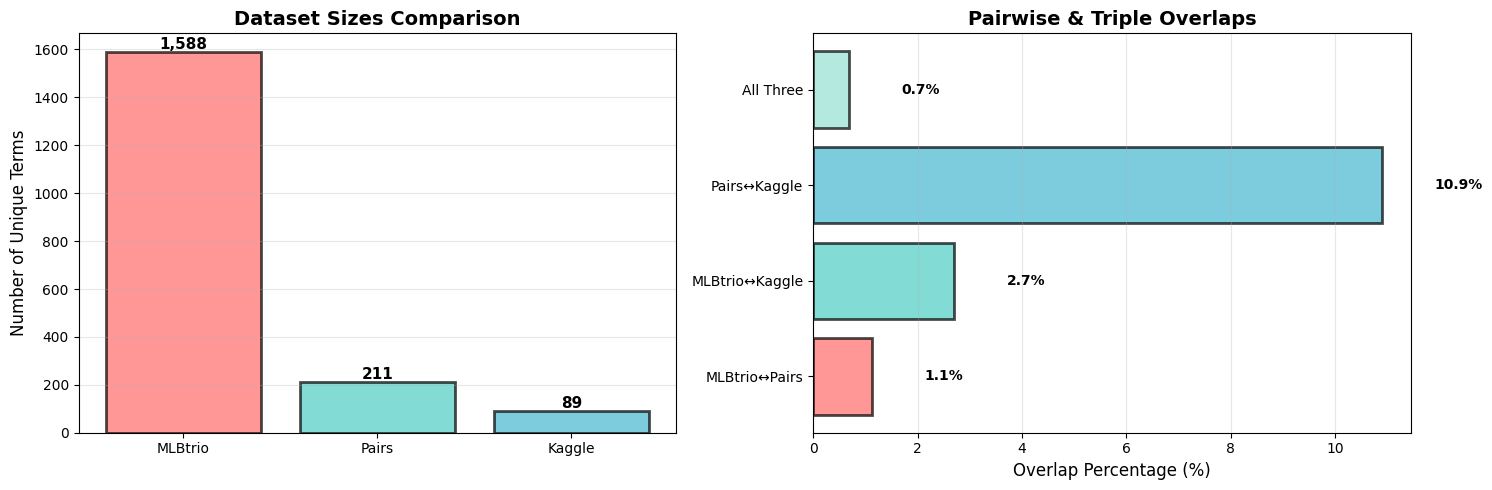

In [52]:
# --- Create sets of slang terms (normalized) ---
slang_mlbtrio = set(df_mlbtrio.Slang.str.lower())
slang_pair = set(chain.from_iterable(slang_lists))
slang_kaggle  = set(df_kaggle.Slang.str.lower())
print(f"Total unique slang terms in slang_kaggle: {len(slang_kaggle)}")
# --- Compute pairwise intersections and differences ---

# Pair 1: MLBtrio vs Pairs
intersection_1_2 = slang_mlbtrio.intersection(slang_pair)
only_in_mlbtrio = slang_mlbtrio - slang_pair
only_in_pairs = slang_pair - slang_mlbtrio

# Pair 2: MLBtrio vs Kaggle
intersection_1_3 = slang_mlbtrio.intersection(slang_kaggle)
only_in_kaggle_vs_mlbtrio = slang_kaggle - slang_mlbtrio

# Pair 3: Pairs vs Kaggle
intersection_2_3 = slang_pair.intersection(slang_kaggle)
only_in_kaggle_vs_pairs = slang_kaggle - slang_pair

# Triple intersection (all three)
intersection_all = slang_mlbtrio.intersection(slang_pair).intersection(slang_kaggle)

# --- Print comprehensive summary ---
print("=" * 70)
print("SLANG DICTIONARY COMPARISON - THREE DATASETS")
print("=" * 70)

print(f"\nDataset Sizes:")
print(f"  MLBtrio/genz-slang-dataset: {len(slang_mlbtrio):,} unique terms")
print(f"  Programmer-RD-AI/genz-slang-pairs-1k: {len(slang_pair):,} unique terms")
print(f"  Gen Z Words and Phrases Dataset: {len(slang_kaggle):,} unique terms")

print(f"\nPairwise Overlaps:")
print(f"  MLBtrio vs Pairs: {len(intersection_1_2)} shared ({len(intersection_1_2) / len(slang_mlbtrio) * 100:.2f}% of MLBtrio)")
print(f"  MLBtrio vs Kaggle: {len(intersection_1_3)} shared ({len(intersection_1_3) / len(slang_mlbtrio) * 100:.2f}% of MLBtrio)")
print(f"  Pairs vs Kaggle: {len(intersection_2_3)} shared ({len(intersection_2_3)/len(slang_pair)*100:.2f}% of Pairs)")

print(f"\nTriple Intersection (in all three): {len(intersection_all)} terms")

print(f"\nUnique Terms (only in one dataset):")
print(f"  Only in MLBtrio: {len(only_in_mlbtrio):,}")
print(f"  Only in Pairs: {len(only_in_pairs):,}")
print(f"  Only in Kaggle: {len(only_in_kaggle_vs_pairs):,}")

# --- Visualizations ---

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: Dataset sizes
ax1 = axes[0]
dataset_names = ['MLBtrio', 'Pairs', 'Kaggle']
dataset_sizes = [len(slang_mlbtrio), len(slang_pair), len(slang_kaggle)]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax1.bar(dataset_names, dataset_sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Unique Terms', fontsize=12)
ax1.set_title('Dataset Sizes Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar, size in zip(bars, dataset_sizes):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(size):,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Chart 2: Overlap percentages
ax2 = axes[1]
overlap_labels = ['MLBtrio↔Pairs', 'MLBtrio↔Kaggle', 'Pairs↔Kaggle', 'All Three']
overlap_percentages = [
    len(intersection_1_2) / max(len(slang_mlbtrio), len(slang_pair)) * 100,
    len(intersection_1_3) / max(len(slang_mlbtrio), len(slang_kaggle)) * 100,
    len(intersection_2_3) / max(len(slang_pair), len(slang_kaggle)) * 100,
    len(intersection_all) / max(len(slang_mlbtrio), len(slang_pair), len(slang_kaggle)) * 100
]

ax2.barh(overlap_labels, overlap_percentages,
         color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3'],
         alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_xlabel('Overlap Percentage (%)', fontsize=12)
ax2.set_title('Pairwise & Triple Overlaps', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(overlap_percentages):
    ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('three_dataset_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Since only 18 slang terms overlap between the two datasets, there is a clear justification for merging them. However, before doing so, we need to align their structures so that both contain the same columns: Slang, Description, Example, and Context. The Programmer-RD-AI/genz-slang-pairs-1k dataset includes example sentences and normalized text, and we generated the slang terms from that text using a large language model (LLM) to detect them. Now that we have the terms, we observe that some slang terms appear in multiple examples, and in some cases, a single example contains multiple slang terms.

## Aligning MLBtrio
In this section the goal is to create a new Informal_Text column, the same way it is in the Pairs dataset. 

### Addition of informal text column that uses slang words
Then a new prompt is created to guide the LLM to adequately perform its task, rewriting normal English text so that the purpose aligns with the original slang meaning. This ensures the refined text captures the same sentiment/intent as the slang.

In [ ]:
prompt_informal_with_slang = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio,
    prompt_template=prompt_informal_with_slang,
    output_column="Informal_Text"
)
df_mlbtrio.Informal_Text

See the new column created in the dataset

In [ ]:
df_mlbtrio.head(5)

Save the dataset to a file

In [ ]:
df_mlbtrio.to_csv(genz_slang, index=False)

### Addition of informal text column that does NOT contain slang words


In [ ]:
prompt_informal   = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio.head(5),
    prompt_template=prompt_informal,
    output_column="Informal_Text_Without_Slang"
)
df_mlbtrio.Informal_Text_Without_Slang

In [ ]:
df_mlbtrio.head(5)

In [ ]:
df_mlbtrio.to_csv(genz_slang, index=False)

### Formal text addition

In [ ]:
prompt_formal = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use formal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio,
    prompt_template=prompt_formal,
    output_column="Formal_Text"
)
df_mlbtrio.Formal_Text

In [ ]:
df_mlbtrio.head(5)

In [ ]:
df_mlbtrio.to_csv(basepath + genz_slang, index=False)

## Aligning Kaggle Gen Z words

In this section we want align the Kaggle dataset to have the same columns as the MLBtrio dataset. 

In [83]:
df_kaggle = pd.read_csv(basepath + gen_zz_words)

In [22]:
prompt_informal   = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_kaggle = client.batch_process(
    df_kaggle,
    prompt_template=prompt_informal,
    output_column="Informal_Text_Without_Slang"
)
df_kaggle.Informal_Text_Without_Slang

Processing to Informal_Text_Without_Slang: 100%|██████████| 204/204 [00:53<00:00,  3.79it/s]


0               That brand new tune is a real hum-ditty!
1           I'm skedaddling, catch you on the flip side.
2      She was heavily criticized and shunned followi...
3                              I'm taking it easy today.
4                                   That video was awks.
                             ...                        
199                               Why are you so bitter?
200                            Nailed that presentation!
201                        Was that a subtle jab at all?
202              Keep your eyes open to what's going on.
203                    She has such a voluptuous figure.
Name: Informal_Text_Without_Slang, Length: 204, dtype: object

In [84]:
df_kaggle = df_kaggle[['Slang', 'Description', 'Example', 'Informal_Text_Without_Slang', 'Popularity']]

In [85]:
df_kaggle.head(5)

,Slang,Description,Example,Informal_Text_Without_Slang,Popularity
0,Bop,A song that's really good.,That new track is a bop.,That fresh tune is a real humdinger.,Medium
1,Bounce,To leave or exit.,"I'm bouncing, see you later.","I've got to split, catch you soon.",Medium
2,Cancelled,Publicly denounced and rejected.,She got cancelled after that post.,She was publicly denounced following that post.,High
3,Chill,Relaxed or easy-going.,I'm just chilling today.,I'm taking it easy today.,High
4,Cringe,Embarrassing or awkward.,That video was cringe.,That video was mortifyingly awkward.,High


In [65]:
df_kaggle.to_csv(gen_zz_words, index=False)

### Context field addition

In [86]:
prompt_context = """You are a conversational analysis expert specializing in concise context descriptions. Output exactly 2-3 sentences. Maximum 40 words.

Slang: {Slang}
Meaning: {Description}
Example: {Example}

Output 2-3 sentences describing WHEN, WHERE, and WHO uses this term. Format: [social context and usage]
Requirements:
- NO QUOTES, NO BRACKETS, NO META-COMMENTARYs
- Do NOT write the slang term itself in the context
- Describe the usage, not the slang word
- Focus on: social setting (who, when, where), sentiment/tone, demographics

Good examples:
Typically used in conversations to celebrate success, achievements, or positive outcomes
Originally used in activist circles, it has since been co-opted and sometimes used sarcastically.
Often used in informal speech to indicate imminent action, popular in certain dialects of English.


Example text: {Example}

Context:"""

df_kaggle = client.batch_process(
    df_kaggle,
    prompt_template=prompt_context,
    output_column="Context"
)
df_kaggle.Context

Processing to Context: 100%|██████████| 204/204 [03:10<00:00,  1.07it/s]


0      Typically used among friends or on social medi...
1      Often employed casually among friends or peers...
2      Primarily employed in digital discussions, oft...
3      Casual setting among friends or peers, often u...
4      Typically used by younger generations in casua...
                             ...                        
199    Typically utilized in casual conversations amo...
200    Typically employed in casual conversations amo...
201    In casual conversations among teenagers and yo...
202    Often employed in contemporary discussions foc...
203    Often utilized among peers in casual social se...
Name: Context, Length: 204, dtype: object

In [88]:
df_kaggle = df_kaggle[['Slang', 'Description', 'Example', 'Context', 'Informal_Text_Without_Slang', 'Popularity']]

In [89]:
df_kaggle.head(5)

,Slang,Description,Example,Context,Informal_Text_Without_Slang,Popularity
0,Bop,A song that's really good.,That new track is a bop.,Typically used among friends or on social medi...,That fresh tune is a real humdinger.,Medium
1,Bounce,To leave or exit.,"I'm bouncing, see you later.",Often employed casually among friends or peers...,"I've got to split, catch you soon.",Medium
2,Cancelled,Publicly denounced and rejected.,She got cancelled after that post.,"Primarily employed in digital discussions, oft...",She was publicly denounced following that post.,High
3,Chill,Relaxed or easy-going.,I'm just chilling today.,"Casual setting among friends or peers, often u...",I'm taking it easy today.,High
4,Cringe,Embarrassing or awkward.,That video was cringe.,Typically used by younger generations in casua...,That video was mortifyingly awkward.,High


In [91]:
df_kaggle.to_csv(basepath + gen_zz_words, index=False)

## Aligning Pairs

In this section the Pairs dataset is asligned to the MLBtrio dataset. A Description and the Context fields are added.

In [4]:
df_pairs = pd.read_csv(basepath + genz_slang_pairs)

The slang column have some duplicates. This entries will kept and removed later in this analysis.

In [5]:
df_pairs.Slang[5]

'tired, chill'

Split of Multi-Slang Entries into multiple entries

In [6]:
def split_multi_slang(df):
    """
    Convert multi-slang entries into separate rows
    E.g., "vibing, no cap" becomes two rows with same Example
    """
    rows = []
    for idx, row in df.iterrows():
        slang_terms = [s.strip() for s in row['Slang'].split(',')]

        for slang in slang_terms:
            new_row = row.copy()
            new_row['Slang'] = slang  # Single term
            new_row['Original_Slang_List'] = ','.join(slang_terms)  # Keep reference
            rows.append(new_row)

    return pd.DataFrame(rows)

# Apply transformation
df_split = split_multi_slang(df_pairs)

print(f"Before: {len(df_pairs)} rows, {df_pairs['Slang'].nunique()} unique terms")
print(f"After: {len(df_split)} rows, {df_split['Slang'].nunique()} unique terms")

Before: 1005 rows, 378 unique terms
After: 1372 rows, 242 unique terms


In [86]:
df_unique = df_split.groupby('Slang').first().reset_index()
df_unique
# Result: 378 rows (one per unique slang term)

,Slang,Example,Informal_Text_Without_Slang,Original_Slang_List
0,"""hella""",I'm hella drained today.,I'm feeling really tired today.,"""hella"""
1,"""java"" is a common misspelling or shortening o...",I'm just finna snag some java before I dip.,I'm just going to grab some coffee before I he...,"finna,java (in this context,""java"" is a common..."
2,"""mad""",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...,"""mad"""
3,Chillin',"Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and...",Chillin'
4,Netflix,I'm just chillin' and gonna Netflix and chill ...,I'm just going to relax and watch a movie toni...,"chillin,Netflix,chill"
...,...,...,...,...
237,yolo,"I'm finna get some coffee, yolo? Do you wanna ...",I'm going to grab some coffee. Do you want to ...,"finna,yolo"
238,z's,"I'm totally drained today, need to catch some ...","I'm really tired today, I think I need some rest.",z's
239,z's (Z's stands for sleep),"I'm super drained today, I gotta catch some z's.","I'm really tired today, I think I need a nap.",z's (Z's stands for sleep)
240,zapped,I'm mad zapped after pulling a midnight cram s...,I'm so tired after staying up all night studying.,zapped


In [87]:
df_aggregated = df_split.groupby('Slang').agg({
    'Example': lambda x: list(x),
    'Informal_Text_Without_Slang': lambda x: list(x)
}).reset_index()
# Then generate a single Description/Context based on all examples
df_aggregated

,Slang,Example,Informal_Text_Without_Slang
0,"""hella""","[I'm hella drained today., I'm hella drained t...","[I'm feeling really tired today., I'm feeling ..."
1,"""java"" is a common misspelling or shortening o...",[I'm just finna snag some java before I dip.],[I'm just going to grab some coffee before I h...
2,"""mad""",[I'm mad tired today 'cause I pulled an all-ni...,[I'm really tired today because I stayed up la...
3,Chillin',"[Fr, I’m just chillin’ at home tonight, no cap...","[Yeah, I think I'm going to stay in tonight an..."
4,Netflix,[I'm just chillin' and gonna Netflix and chill...,[I'm just going to relax and watch a movie ton...
...,...,...,...
237,yolo,"[I'm finna get some coffee, yolo? Do you wanna...",[I'm going to grab some coffee. Do you want to...
238,z's,"[I'm totally drained today, need to catch some...","[I'm really tired today, I think I need some r..."
239,z's (Z's stands for sleep),"[I'm super drained today, I gotta catch some z...","[I'm really tired today, I think I need a nap.]"
240,zapped,[I'm mad zapped after pulling a midnight cram ...,[I'm so tired after staying up all night study...


In [7]:
df_unique = df_split.loc[df_pairs.groupby('Slang')['Example'].apply(lambda x: x.str.len().idxmin())]
df_unique

,Slang,Example,Informal_Text_Without_Slang,Original_Slang_List
45,"""hella""",I'm hella drained today.,I'm feeling really tired today.,"""hella"""
83,"""mad""",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...,"""mad"""
897,Chillin',"Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and...",Chillin'
943,Chillin',"Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","Chillin',vibing"
943,vibing,"Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","Chillin',vibing"
...,...,...,...,...
892,yeet,"Yo, wanna yeet for some chow later? 🔥","Hey, do you want to go grab some food later?",yeet
459,yo,"Yo, did you catch the new ep of that show yest...","Hey, did you see the new episode of that show ...",yo
484,z's,"Lowkey exhausted today, I gotta catch some Z's.","I'm just really tired today, I think I need so...",z's
64,z's (Z's stands for sleep),"I'm super drained today, I gotta catch some z's.","I'm really tired today, I think I need a nap.",z's (Z's stands for sleep)


In [74]:
# Create one Description per slang term (378 rows)
df_terms = df_pairs.groupby('Slang').agg({
    'Example': lambda x: list(x)[:5],  # Keep up to 5 examples
    'Informal_Text_Without_Slang': 'first'
}).reset_index()

# Generate Description using multiple examples as context
# This gives you a comprehensive understanding of the term
df_terms

,Slang,Example,Informal_Text_Without_Slang
0,"""hella""","[I'm hella drained today., I'm hella drained t...",I'm feeling really tired today.
1,"""mad""",[I'm mad tired today 'cause I pulled an all-ni...,I'm really tired today because I stayed up lat...
2,Chillin',"[Fr, I’m just chillin’ at home tonight, no cap.]","Yeah, I think I'm going to stay in tonight and..."
3,"Chillin', vibing","[Yo, I'm just chillin' at my place and vibing ...","Hey, I'm just relaxing at home and listening t..."
4,"OOTD, vibing, no cap","[OOTD, just vibing with the crew today, no cap.]",I'm just planning to hang out with friends thi...
...,...,...,...
373,yeet,"[I'm down bad but gotta yeet to work anyway., ...",I'm just really tired today but I still have t...
374,yo,"[Yo, did you catch the new ep of that show yes...","Hey, did you see the new episode of that show ..."
375,z's,"[I'm totally drained today, need to catch some...","I'm really tired today, I think I need some rest."
376,z's (Z's stands for sleep),"[I'm super drained today, I gotta catch some z...","I'm really tired today, I think I need a nap."


In [28]:
# Get the Slang
df_mlbtrio = pd.read_csv(basepath + genz_slang)

for i in range(5):
    print("Slang: " + df_mlbtrio.Slang[i] +
          ", Description: " + df_mlbtrio.Description[i] +
          ", Example: " + df_mlbtrio.Example[i] +
          ", Informal_Text: " + df_mlbtrio.Informal_Text[i])

Slang: W, Description: Shorthand for win, Example: Got the job today, big W!, Informal_Text: Nailed it today, big win!
Slang: L, Description: Shorthand for loss/losing, Example: I forgot my wallet at home, that’s an L., Informal_Text: Dang it, left my wallet at home – that's a loss for sure!
Slang: L+ratio, Description: Response to a comment or action on the internet that is particularly bad., Example: Your tweet got 5 likes and 100 replies calling you out. L + ratio., Informal_Text: Dang, your tweet only managed five likes but a hundred people called you out on it. Big ol' ratio, mate!
Slang: Dank, Description: excellent or of very high quality, Example: That meme is so dank!, Informal_Text: That meme's fire as hell!
Slang: Cheugy, Description: Derogatory term for Millennials. Used when millennials are perceived to be excessively attempting to be trendy or stylish., Example: That phrase is so cheugy, no one says that anymore., Informal_Text: Man, that's totally cringey – nobody's usin

In [60]:
df_unique = pd.read_csv(basepath + "genz-slang-pairs-1k-unique.csv")

In [61]:
# Prompt for generating Description field
prompt_context = prompt_context = """You are a linguistics expert specializing in concise definitions. Output exactly 1 line. Maximum 10 words.

Slang: {Slang}
Example: {Example}

Output ONE line only. Format: [short definition]
No brackets, no labels, no explanation, no example, no context, not allowed to used the Slang to describe itself.

Bad: The term "hella" is an informal contraction of "hell of," originating from California's Bay Area in the United States. It is used as an intensifier to emphasize a strong feeling, emotion, or degree. In the sentence "I'm hella drained today," the speaker is expressing extreme feelings of exhaustion or tiredness.
Good: being politically aware
Good: The greatest of all time
Good: Fam is a shorter word for family, but don't be fooled– it can be used to describe your friends or the way Millennials use "bro".

Definition:"""

df_unique = client.batch_process(
    df_unique,
    prompt_template=prompt_context,
    output_column="Description"
)
df_unique.Description

Processing to Description: 100%|██████████| 650/650 [03:41<00:00,  2.93it/s]


0                  Intensifier meaning extremely or very
1                 Angry or frustrated, often informally.
2         Casually relaxing, informally enjoying leisure
3      Casual relaxation, typically with social inter...
4      Enjoying oneself in a relaxed, positive manner...
                             ...                        
645    Casual exclamation indicating enthusiasm or ap...
646    Informal greeting, often used in casual conver...
647    Sleep (noun): informal abbreviation for "sleep...
648    A common slang term referring to sleep. Exampl...
649              intensified exasperation or frustration
Name: Description, Length: 650, dtype: object

In [62]:
df_unique.head(5)

,Slang,Description,Example,Informal_Text_Without_Slang
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and..."
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."


In [13]:
df_unique = df_unique[['Slang', 'Description', 'Example', 'Informal_Text_Without_Slang']]
df_unique.head(5)


,Slang,Description,Example,Informal_Text_Without_Slang
45,"""hella""","The term ""hella"" is an informal contraction of...",I'm hella drained today.,I'm feeling really tired today.
83,"""mad""","The slang term ""mad"" as used in the sentence ""...",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...
897,Chillin',"The slang term ""chillin'"" as used in the phras...","Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and..."
943,Chillin',"The term ""chillin'"" is a colloquial expression...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."
943,vibing,"The slang term ""vibing,"" as used in the given ...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."


In [63]:
df_unique.to_csv(basepath + "genz-slang-pairs-1k-unique.csv", index=False)

Context fields as there is in the MLBrio dataset

In [77]:
prompt_context = """You are a conversational analysis expert specializing in concise context descriptions. Output exactly 2-3 sentences. Maximum 40 words.

Slang: {Slang}
Meaning: {Description}
Example: {Example}

Output 2-3 sentences describing WHEN, WHERE, and WHO uses this term. Format: [social context and usage]
Requirements:
- NO QUOTES, NO BRACKETS, NO META-COMMENTARYs
- Do NOT write the slang term itself in the context
- Describe the usage, not the slang word
- Focus on: social setting (who, when, where), sentiment/tone, demographics

Good examples:
Typically used in conversations to celebrate success, achievements, or positive outcomes
Originally used in activist circles, it has since been co-opted and sometimes used sarcastically.
Often used in informal speech to indicate imminent action, popular in certain dialects of English.


Example text: {Example}

Context:"""

df_unique = client.batch_process(
    df_unique,
    prompt_template=prompt_context,
    output_column="Context"
)
df_unique.Context

Processing to Context: 100%|██████████| 650/650 [10:20<00:00,  1.05it/s]


0      Typically expressed in casual conversations, p...
1      Typically expressed among peers or casual acqu...
2      Typically utilized among friends or peers duri...
3      In informal settings among friends or peers, o...
4      In casual social settings, often among friends...
                             ...                        
645    In casual, youthful social settings, typically...
646    In casual settings among friends or peers, oft...
647    Commonly used among friends and peers during c...
648    Typically utilized in informal settings among ...
649    Often utilized among young adults or students ...
Name: Context, Length: 650, dtype: object

In [78]:
df_unique.head(5)

,Slang,Description,Example,Informal_Text_Without_Slang,Context
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,I'm feeling really tired today.,"Typically expressed in casual conversations, p..."
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...,Typically expressed among peers or casual acqu...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and...",Typically utilized among friends or peers duri...
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","In informal settings among friends or peers, o..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","In casual social settings, often among friends..."


In [79]:
df_unique = df_unique[['Slang', 'Description', 'Example', 'Context', 'Informal_Text_Without_Slang']]
df_unique.head(5)


,Slang,Description,Example,Context,Informal_Text_Without_Slang
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,"Typically expressed in casual conversations, p...",I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,Typically expressed among peers or casual acqu...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.",Typically utilized among friends or peers duri...,"Yeah, I think I'm going to stay in tonight and..."
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","In informal settings among friends or peers, o...","Hey, I'm just relaxing at home and listening t..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","In casual social settings, often among friends...","Hey, I'm just relaxing at home and listening t..."


In [80]:
df_unique.to_csv(basepath + "genz-slang-pairs-1k-unique.csv", index=False)

## Data assembly

In [7]:
df_unique = pd.read_csv(basepath + "genz-slang-pairs-1k-unique.csv")
df_mlbtrio = pd.read_csv(basepath + genz_slang)
df_kaggle = pd.read_csv(basepath + gen_zz_words)

In [40]:
# Select only the columns you need and rename last column
columns_to_keep = ["Slang", "Description", "Example", "Context", "Informal_Text_Without_Slang"]

df_unique_filtered = df_unique[columns_to_keep].rename(columns={"Informal_Text_Without_Slang": "Neutral_Text"})
df_mlbtrio_filtered = df_mlbtrio[columns_to_keep].rename(columns={"Informal_Text_Without_Slang": "Neutral_Text"})
df_kaggle_filtered = df_kaggle[columns_to_keep].rename(columns={"Informal_Text_Without_Slang": "Neutral_Text"})

# Merge all three datasets
df_merged = pd.concat([df_unique_filtered, df_mlbtrio_filtered, df_kaggle_filtered], ignore_index=True)
print(f"Merged dataset shape: {df_merged.shape}")

Merged dataset shape: (2633, 5)


In [41]:
df_merged.head(5)

,Slang,Description,Example,Context,Neutral_Text
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,"Typically expressed in casual conversations, p...",I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,Typically expressed among peers or casual acqu...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.",Typically utilized among friends or peers duri...,"Yeah, I think I'm going to stay in tonight and..."
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","In informal settings among friends or peers, o...","Hey, I'm just relaxing at home and listening t..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","In casual social settings, often among friends...","Hey, I'm just relaxing at home and listening t..."


In [42]:
df_merged.to_csv(basepath + "genz_slang_data.csv", index=False)

In [43]:
analysis_merged : Dict = analyser.analyze(
    df_merged,
    column='Slang',
    dataset_name='Gen Z Words and Phrases Dataset'
)
analyser.show_total_statistics(analysis_merged)
analyser.show_duplication_analysis(analysis_merged)


DATASET ANALYSIS: Gen Z Words and Phrases Dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,"2,633"
1,Unique (Case-Sensitive),"1,901"
2,Unique (Lowercase),"1,844"


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),30.0%
1,Most Common Term,'drained'
2,Most Common Count,48
3,Original Cases,['drained']


The obtained duplication is of 30%, therefore a drop duplicate stage is added. This stage is case sensitive, meaning that same words but with different capitalizations will be reckoned as different due to the different descriptions and meaning provided by the dictionaries.

In [46]:
df_merged_nodup = df_merged.drop_duplicates(subset=["Slang"])

analysis_merged : Dict = analyser.analyze(
    df_merged_nodup,
    column='Slang',
    dataset_name='Gen Z Words and Phrases Dataset'
)
analyser.show_total_statistics(analysis_merged)
analyser.show_duplication_analysis(analysis_merged)

df_merged_nodup.to_csv(basepath + "genz_slang_data.csv", index=False)


DATASET ANALYSIS: Gen Z Words and Phrases Dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,"1,901"
1,Unique (Case-Sensitive),"1,901"
2,Unique (Lowercase),"1,844"


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),3.0%
1,Most Common Term,'fam'
2,Most Common Count,3
3,Original Cases,"['fam', 'Fam', 'FAM']"


The two main datasets used in this project from this point onward are the merged Gen Z dataset and the TL;DR corpus. As shown above, both datasets have manageable sizes (TL;DR: 116,722 entries; Gen Z: 6,553 entries). Both datasets are stored as CSV files with UTF-8 encoded text, contain no missing values or duplicate entries, and their length distributions will be analyzed in the following sections along with other relevant metrics.

## TL;DR data analysis

### Exploratory Data Analysis

Load the TL;DR dataset from Hugging Face and display the split percentages (train/validation/test) and sample data structure.

In [4]:

print("Loading TL;DR dataset from Hugging Face...")
dataset = load_dataset("trl-lib/tldr", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)

train_ds = dataset["train"]
val_ds = dataset["validation"]
test_ds = dataset["test"]

print(f"Dataset sizes: Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)}")

total = len(train_ds) + len(val_ds) + len(test_ds)
print(f"Dataset split percentages: Train={len(train_ds)/total*100:.2f}%, Val={len(val_ds)/total*100:.2f}%, Test={len(test_ds)/total*100:.2f}%")
pd.DataFrame(train_ds).head(5)

Loading TL;DR dataset from Hugging Face...


Generating train split:   0%|          | 0/116722 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6447 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6553 [00:00<?, ? examples/s]

Dataset sizes: Train=116722, Val=6447, Test=6553
Dataset split percentages: Train=89.98%, Val=4.97%, Test=5.05%


,prompt,completion
0,SUBREDDIT: r/relationships\n\nTITLE: I (f/22) ...,I still have contact with an old ex's friends...
1,SUBREDDIT: r/loseit\n\nTITLE: SV & NSV! Keepin...,"Progress is still happening, even when you th..."
2,SUBREDDIT: r/relationships\n\nTITLE: Me [19F] ...,My skin is scarred badly; what could I do/say...
3,SUBREDDIT: r/personalfinance\n\nTITLE: Priorit...,$14k in student debt (all <5%) and need to sa...
4,SUBREDDIT: r/relationships\n\nTITLE: My[25m] g...,"GF is a meanie-bo-beanie when I'm nice, and a..."


As we can observe, the split for the TL;DR dataset has percentages: Train=89.98%, Val=4.97%, Test=5.05%. It consist of a prompt and a completion. We clean the prompt and completion fields by removing newlines and extra whitespace to standardize text formatting across the dataset.

In [5]:

train_ds = train_ds.map(normalize_text, desc="Normalizing train")
val_ds = val_ds.map(normalize_text, desc="Normalizing validation")
test_ds = test_ds.map(normalize_text, desc="Normalizing test")

Normalizing train:   0%|          | 0/116722 [00:00<?, ? examples/s]

Normalizing validation:   0%|          | 0/6447 [00:00<?, ? examples/s]

Normalizing test:   0%|          | 0/6553 [00:00<?, ? examples/s]

We merge the 3 splits to simplify the data analysis

In [4]:
df_tldr = pd.concat([train_ds.to_pandas(), test_ds.to_pandas(), val_ds.to_pandas()], ignore_index=True)
print(f"\nCombined dataset shape: {df_tldr.shape}")


Combined dataset shape: (129722, 2)


First we start with language identification. We want to make sure we are having a dataset with english text. With a completely english dataset we can use english-specific tokenizers.

In [5]:
langauge = sample_lang_distribution(df_tldr)
print(langauge)

en    1.0
Name: proportion, dtype: float64


Verify that there are no null values in the prompt and completion columns to ensure data quality.

In [6]:
missing_counts = df_tldr.isnull().sum()
missing_percent = (df_tldr.isnull().sum() / len(df_tldr)) * 100

print("\nMissing values by column for the whole TL;DR dataset:")
for col, count in missing_counts.items():
    pct = missing_percent[col]
    print(f"  {col}: {count} ({pct:.4f}%)")


Missing values by column for the whole TL;DR dataset:
  prompt: 0 (0.0000%)
  completion: 0 (0.0000%)


Calculate word lengths for prompts and completions, then derive compression ratios to understand text reduction patterns in the dataset.

In [5]:
tldr_stats, stats_summary = compute_tldr_stats(df_tldr)
display(tldr_stats, include_index=False)
display(stats_summary, include_index=False)

,prompt_word_length,completion_word_length,compression_ratio
0,356,40,8.900000
1,215,28,7.678571
2,213,27,7.888889
3,190,25,7.600000
4,278,26,10.692307
...,...,...,...
129717,210,26,8.076923
129718,347,34,10.205882
129719,409,22,18.590908
129720,333,32,10.406250


,Metric,Prompt Length,Completion Length,Compression Ratio
0,Mean,266.425417,27.030419,10.244642
1,Variance,6027.481201,34.679258,12.742166
2,Std Dev,77.636855,5.888910,3.569617
3,Coefficient of Variation,0.291402,0.217862,0.348437
4,Max,442.000000,47.000000,52.428564
5,Min,11.000000,7.000000,0.343750


Two-part visualization: overlaid histograms with mean and ±1σ bands showing the distribution patterns, followed by box plots comparing quartile ranges between prompts and completions to highlight compression ratios and statistical spread.

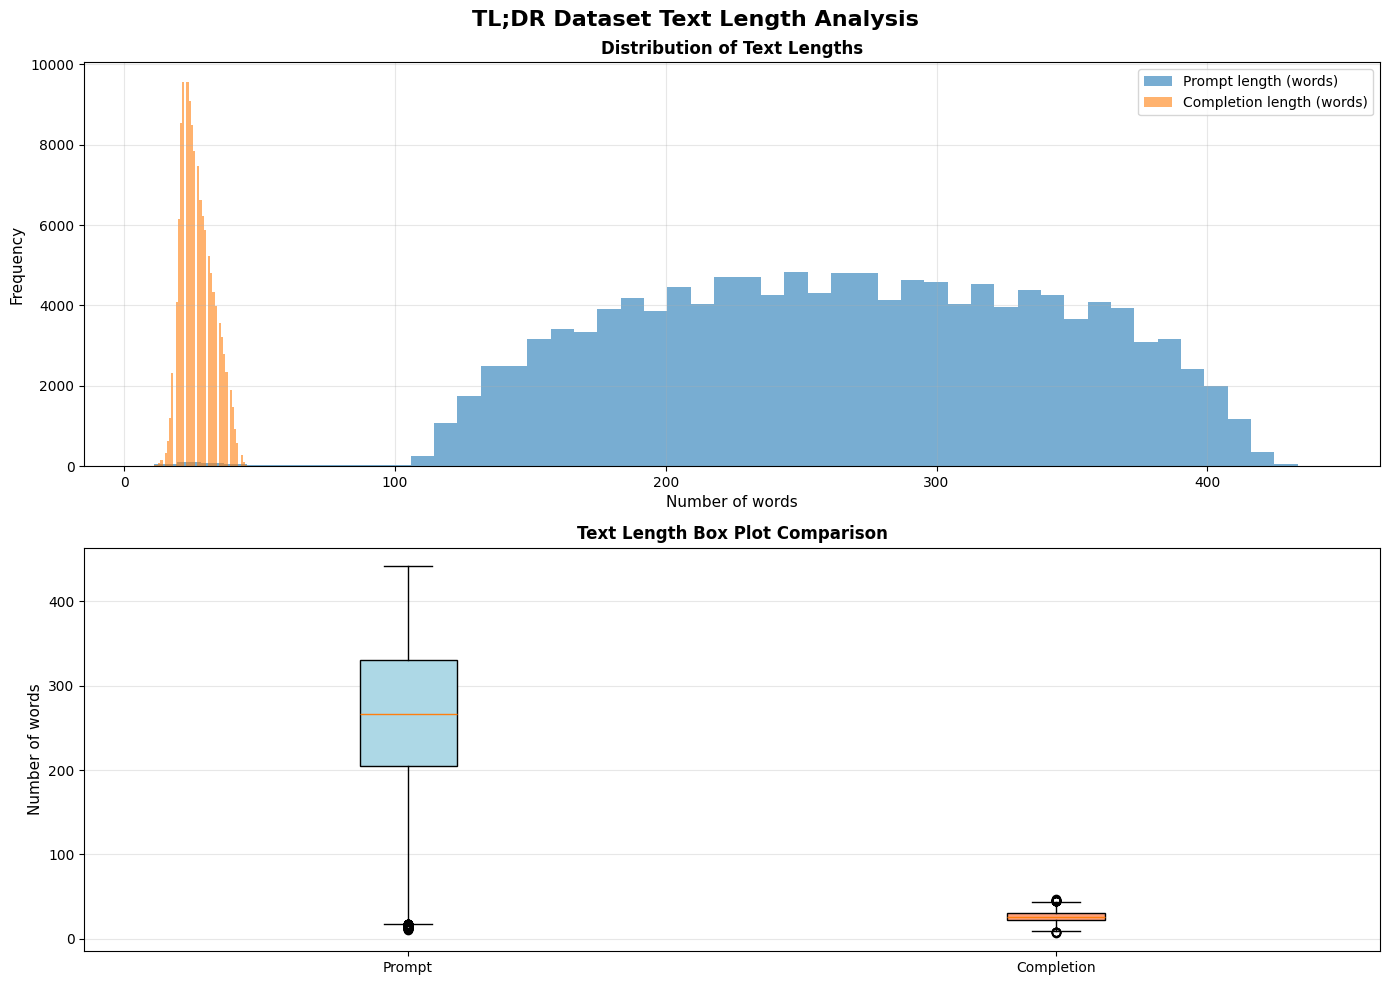

In [6]:
from scripts.libs.tldr_plots import plot_tldr_analysis
plot_tldr_analysis(tldr_stats)

Calculate the intersection-over-union (unigram-level) between prompts and completions to measure semantic overlap and textual alignment.

In [9]:
import numpy as np
from scripts.libs.tldr_stats import compute_alignment_stats

tldr_alignment_stats = compute_alignment_stats(df_tldr)

tldr_alignment_stats['iou_mean'] = float(np.mean(tldr_alignment_stats['iou']))
tldr_alignment_stats['iou_p95'] = float(np.percentile(tldr_alignment_stats['iou'], 95))
tldr_alignment_stats['len_ratio_mean_chars'] = float(np.mean(tldr_alignment_stats['len_ratio']))
tldr_alignment_stats['len_ratio_p95_chars'] = float(np.percentile(tldr_alignment_stats['len_ratio'], 95))

display(tldr_alignment_stats.describe())

,iou,len_ratio,iou_mean,iou_p95,len_ratio_mean_chars,len_ratio_p95_chars
count,129722.000000,129722.000000,129722.000000,129722.000000,1.297220e+05,129722.000000
mean,0.096537,0.111022,0.096537,0.158879,1.110219e-01,0.188453
std,0.034110,0.059652,0.000000,0.000000,2.775568e-17,0.000000
min,0.000000,0.035389,0.096537,0.158879,1.110219e-01,0.188453
25%,0.072626,0.079658,0.096537,0.158879,1.110219e-01,0.188453
50%,0.091954,0.100735,0.096537,0.158879,1.110219e-01,0.188453
75%,0.115385,0.129909,0.096537,0.158879,1.110219e-01,0.188453
max,0.514286,2.423077,0.096537,0.158879,1.110219e-01,0.188453


Convert prompt and completion fields to token IDs using the GPT-2 tokenizer, capturing token lengths for both fields and their sum. Compute mean and 95th percentile statistics for prompt, completion, and total token lengths to understand model input requirements.

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
from scripts.libs.tldr_stats import tokenize_texts

token_stats, token_summary = tokenize_texts(df_tldr, None, tokenizer)
display(token_stats, index=False)
display(token_summary, index=False)


,prompt_tok_len,completion_tok_len,total_tok_len
0,417,46,463
1,286,36,322
2,278,34,312
3,263,39,302
4,350,41,391
...,...,...,...
129717,271,35,306
129718,442,41,483
129719,462,24,486
129720,402,37,439


,Metric,Value
0,prompt_tok_mean,329.40
1,prompt_tok_p95,472.00
2,completion_tok_mean,32.44
3,completion_tok_p95,45.00
4,total_tok_p95,506.00


Implement and evaluate a simple baseline model that echoes the first 32 tokens of each prompt. Measure prediction quality using ROUGE and chrF metrics against the ground-truth completions.

In [13]:
metrics = evaluate_echo_baseline(test_ds, tokenizer)
display(metrics)

,Metric,Value
0,ROUGE-1,0.2250
1,ROUGE-2,0.0755
2,ROUGE-L,0.1761
3,chrF,19.3121


The TL;DR dataset was explored to understand its structure and content. The dataset consists of 129,722 examples, each containing a Reddit post (*prompt*) and its corresponding TL;DR summary (*completion*). No missing values were found in either column.

Text length analysis showed that posts contain an average of about 266 words, while summaries average around 27 words, indicating a high level of compression (roughly a 10:1 ratio). This characteristic length can be ilustrated by generating a histogram of the text lengths, which shows that the spread (standard deviation) of the completion is seven times smaller than the prompt, therefore TL;DR summaries have a very consistent length that we aim to keep in the output of our model.

In order to assess the quality of the TL;DR dataset we perform a more thorough analysis with the goal of evaluating data cleanliness, diversity, alignment between prompts and summaries, token length distributions, potential privacy concerns, and establishing a baseline for summarization performance.

These analysis shows that the dataset appears to be high-quality and predominantly English, as evidenced by the language fraction of 1.0 for the training set. Prompt–completion alignment metrics show that the lexical overlap is low (mean Jaccard ~0.097). 

Tokenization statistics reveal that 95% of prompts fit within 472 tokens and completions within 45 tokens, with the combined 95th percentile at 506 tokens—guiding a reasonable maximum sequence length for model training. 

Finally, the echo baseline, which simply outputs truncated prompts, performs poorly (ROUGE-1 ≈ 0.22, ROUGE-2 ≈ 0.07, ROUGE-L ≈ 0.17, chrF ≈ 19.31), confirming that the dataset presents a non-trivial summarization task and leaves substantial room for model improvement. Overall, these metrics indicate a clean, english-focused summarization dataset and a realistic challenge for training models.

Make embeddings

In [6]:
df_genz = pd.read_csv(basepath + "genz_slang_data.csv")

df_genz.head(5)

,Slang,Description,Example,Context,Neutral_Text
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,"Typically expressed in casual conversations, p...",I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,Typically expressed among peers or casual acqu...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.",Typically utilized among friends or peers duri...,"Yeah, I think I'm going to stay in tonight and..."
3,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","In casual social settings, often among friends...","Hey, I'm just relaxing at home and listening t..."
4,OOTD,Outfit of the day,"OOTD, just vibing with the crew today, no cap.",Typically exchanged among young adults on soci...,I'm just planning to hang out with friends thi...


We start with only 5 examples to quickly test our settings before processing hundred of thousands of posts. we want to know if our top_p and our sample ratio is good numbers

Define the overall functions for what we are using

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm
import pandas as pd

# Load model and embeddings (do this once)
model = SentenceTransformer("all-MiniLM-L6-v2")
slang_embeddings = model.encode(df_genz['Neutral_Text'].tolist(), show_progress_bar=True)

def get_slang_for_tldr(tldr_text, top_p):
    """
    Get relevant slang words for a single TL;DR completion.
    Returns: tuple of (slang_string, count)
    """
    tldr_embedding = model.encode([tldr_text])[0]
    similarities = cosine_similarity([tldr_embedding], slang_embeddings)[0]
    top_p_indices = get_top_p_indices(similarities, top_p=top_p)
    
    slang_list = df_genz.iloc[top_p_indices]['Slang'].tolist()
    slang_string = "; ".join(slang_list)
    count = len(slang_list)
    
    return slang_string, count, similarities[top_p_indices].tolist()

def sample_slang_words(slang_string, sample_ratio=0.7):
    """
    Sample a subset of slang words from the semi-colon separated string.
    Returns: tuple of (sampled_string, count)
    """
    slang_list = [s.strip() for s in slang_string.split(";") if s.strip()]
    n_samples = max(1, int(len(slang_list) * sample_ratio))
    sampled = np.random.choice(slang_list, size=n_samples, replace=False)
    sampled_string = "; ".join(sampled)
    count = len(sampled)
    
    return sampled_string, count

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Batches: 100%|██████████| 60/60 [00:04<00:00, 13.26it/s]


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from scripts.libs.top_p import get_top_p_indices
model = SentenceTransformer("all-MiniLM-L6-v2")
slang_embeddings = model.encode(df_genz['Neutral_Text'].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 60/60 [00:04<00:00, 13.11it/s]


In [31]:
def analyze_slang_similarity(tldr_text, top_p):
    """
    For one TL;DR post:
    - Computes similarity against all slangs
    - Returns a DataFrame with: Slang, Similarity score, IsRelevant
    """
    tldr_embedding = model.encode([tldr_text])[0]
    similarities = cosine_similarity([tldr_embedding], slang_embeddings)[0] # Normalize similarities
    #similarities = (similarities - similarities.min()) / (similarities.max() - similarities.min())
    
    # Top-p selection
    top_p_indices = get_top_p_indices(similarities, top_p=top_p)
    top_p_mask = np.zeros_like(similarities, dtype=bool)
    top_p_mask[top_p_indices] = True
    
    # Build result DataFrame
    df_result = pd.DataFrame({
        'Slang': df_genz['Slang'].tolist(),
        'Similarity': similarities,
        'Relevant': top_p_mask
    })
    return df_result

In [32]:
# Usage example for 5 posts
tldr_df_train = train_ds.to_pandas().head(1).copy()
slang_analysis_results = []

for idx, completion in tqdm(enumerate(tldr_df_train['completion']), total=len(tldr_df_train), desc="Analyzing slang similarities"):
    df_slang = analyze_slang_similarity(completion, top_p=0.01)
    slang_analysis_results.append(df_slang)
    
    # Print table (for one example)
    if idx == 0:
        print("All slangs and similarities (Relevant==True means matches top_p):")
        display(df_slang)

# If you want, add summary stats per post
tldr_df_train['relevant_slang_count'] = [df['Relevant'].sum() for df in slang_analysis_results]

print(f"Relevant slang count - Mean: {tldr_df_train['relevant_slang_count'].mean():.2f}, "
      f"Min: {tldr_df_train['relevant_slang_count'].min()}, "
      f"Max: {tldr_df_train['relevant_slang_count'].max()}")
print(df_slang['Similarity'].max())
print(df_slang['Similarity'].min())
display(df_slang['Similarity'].sort_values())
#print(df_slang[912]['Slang'], df_slang[912]['Similarity'])

# Save annotated main data
tldr_df_train.to_csv("tldr_with_slang.csv", index=False)
print(f"\nSaved {len(tldr_df_train)} Reddit posts with all slang analyses.")

sorted_similarities = df_slang['Similarity'].sort_values()
display((df_slang[df_slang['Relevant'] == True]['Similarity'].sort_values()))

print((df_slang[df_slang['Relevant'] == True]).count())


Analyzing slang similarities:   0%|          | 0/1 [00:00<?, ?it/s]

All slangs and similarities (Relevant==True means matches top_p):


,Slang,Similarity,Relevant
0,"""hella""",0.017811,False
1,"""mad""",0.007308,False
2,Chillin',-0.024941,False
3,vibing,-0.013361,False
4,OOTD,0.249189,False
...,...,...,...
1896,Glow Up,-0.083999,False
1897,Cap,-0.023642,False
1898,Dead,0.026233,False
1899,Mood,0.091278,False


Analyzing slang similarities: 100%|██████████| 1/1 [00:00<00:00, 13.52it/s]

Relevant slang count - Mean: 15.00, Min: 15, Max: 15
0.4285431
-0.17923686


363    -0.179237
1114   -0.144636
883    -0.141797
862    -0.136837
988    -0.131507
          ...   
536     0.327428
346     0.340254
675     0.344485
385     0.344561
912     0.428543
Name: Similarity, Length: 1901, dtype: float32


Saved 1 Reddit posts with all slang analyses.


5       0.249189
1214    0.263741
909     0.265353
376     0.266819
672     0.275910
908     0.284614
1274    0.299210
671     0.312940
914     0.315924
951     0.325460
536     0.327428
346     0.340254
675     0.344485
385     0.344561
912     0.428543
Name: Similarity, dtype: float32

Slang         15
Similarity    15
Relevant      15
dtype: int64


In [ ]:
similarity_distributions = []

for idx, completion in tqdm(enumerate(tldr_df_train['completion']), total=len(tldr_df_train)):
    _, similarities, _ = get_slang_similarity_distribution(completion)
    similarity_distributions.append(similarities)  # list of numpy arrays

# Optionally attach as DataFrame columns (each as a vector per row)
tldr_df_train['slang_similarities'] = similarity_distributions


In [ ]:
# For any post, display as a table
example_post_sim = tldr_df_train.iloc[example_idx]['slang_similarities']
all_df = pd.DataFrame({'Slang': slangs, 'Similarity': example_post_sim})
display(all_df.sort_values('Similarity', ascending=False))


The function `get_slang_for_tldr` is first encoding the TL;DR completion and then sompare it to the `Netrual_Text` from the Gen-Z data set. This way we retreive a distribution over the likelyhood of each words. Afterwards, we are using a Top P to get all the words over a certatin thresdhold of likelyhood. Then we are taking some of the words ever the thredshold, since later on will show that these sentences from the Netraul Text is very similar to the TL;DR completion text. 

In [ ]:


# Convert dataset to pandas
tldr_df_train = train_ds.to_pandas().head(5).copy()

# Step 1-5: Create relevant slang with counts
print("Step 1-5: Computing relevant slang words...")
relevant_slang_list = []
relavant_slang_probality_list = []
relevant_slang_count_list = []

for idx, completion in tqdm(enumerate(tldr_df_train['completion']), total=len(tldr_df_train), desc="Computing slang"):
    slang, count = get_slang_for_tldr(completion, top_p=0.01)
    relevant_slang_list.append(slang)
    relevant_slang_count_list.append(count)

tldr_df_train['relevant_slang'] = relevant_slang_list
tldr_df_train['relevant_slang_count'] = relevant_slang_count_list

print(f"Relevant slang - Mean: {np.mean(relevant_slang_count_list):.2f}, "
      f"Min: {np.min(relevant_slang_count_list)}, "
      f"Max: {np.max(relevant_slang_count_list)}")

# Step 6: Sample slang with counts
print("\nStep 6: Sampling slang words...")
sampled_slang_list = []
sampled_slang_count_list = []

for slang_string in tqdm(tldr_df_train['relevant_slang'], desc="Sampling slang"):
    sampled, count = sample_slang_words(slang_string, sample_ratio=0.7)
    sampled_slang_list.append(sampled)
    sampled_slang_count_list.append(count)

tldr_df_train['sampled_slang'] = sampled_slang_list
tldr_df_train['sampled_slang_count'] = sampled_slang_count_list

print(f"Sampled slang - Mean: {np.mean(sampled_slang_count_list):.2f}, "
      f"Min: {np.min(sampled_slang_count_list)}, "
      f"Max: {np.max(sampled_slang_count_list)}")

# Display results
display(tldr_df_train.head(5))

# Save the augmented dataset
tldr_df_train.to_csv("tldr_with_slang.csv", index=False)
print(f"\n✓ Saved {len(tldr_df_train)} Reddit posts with slang annotations")

In [9]:
annotator = SlangAnnotator(genz_data=df_genz)

tldr_df_train = train_ds.to_pandas().head(5).copy()
tldr_df_train, stats = annotator.annotate_dataset(tldr_df_train, top_p=0.05, sample_ratio=0.5)

# Display statistics for how many slang terms were relevant within the top_p and how many of them we have sampled
display(stats.head(5))

# Display results
display(tldr_df_train.head(5))


Sampling slang: 100%|██████████| 5/5 [00:00<?, ?it/s]


,relevant_slang,sampled_slang
mean,80.600000,40.000000
min,78.000000,39.000000
max,83.000000,41.000000
std,1.854724,0.894427


,prompt,completion,relevant_slang,relevant_slang_count,sampled_slang,sampled_slang_count
0,SUBREDDIT: r/relationships TITLE: I (f/22) hav...,I still have contact with an old ex's friends ...,FBFR; Zombie-ing; BFFN; Thirsty; AAYF; FWB; FB...,79,DN; dipped; XYL; SNR; OOTD; no cap; Thirsty; p...,39
1,SUBREDDIT: r/loseit TITLE: SV & NSV! Keeping o...,"Progress is still happening, even when you thi...",NSA; WB; DITYID; FISH; AYDY; JOMO; DGTG; FTBOM...,78,W; APAC; AYDY; A/N; ABTA; HP; Feelsgoodman; NB...,39
2,SUBREDDIT: r/relationships TITLE: Me [19F] wit...,My skin is scarred badly; what could I do/say ...,DIY; IAAD; MYOB; Snatched; Beat your face; OMA...,82,DMY; SMEXI; QOTD; LI; FBO; Normalize; HUYA; LS...,41
3,SUBREDDIT: r/personalfinance TITLE: Prioritize...,$14k in student debt (all <5%) and need to sav...,IAAA; Sheesh; WGACA; DYOR; Gaup; TMA; BOHICA; ...,83,Living Rent-Free; DYOR; OA; zapped; HV; SIR; I...,41
4,SUBREDDIT: r/relationships TITLE: My[25m] girl...,"GF is a meanie-bo-beanie when I'm nice, and an...",GF; KOC; G/F; PYT; GRL; HUYA; IWSN; LHSX; MOOS...,81,<3; MYO; L2G; X; IRL; IWSN; Slay; TTTT; KT; DB...,40


After seening that the embeddings are very evenly distributed we should either only get the very close words as top 5% or even top 2 % or we should implement some temperature

In [10]:
tldr_df_train = train_ds.to_pandas().copy()
tldr_df_train, stats = annotator.annotate_dataset(tldr_df_train, top_p=0.01, sample_ratio=0.3)

# Display statistics for how many slang terms were relevant within the top_p and how many of them we have sampled
display(stats.head(5))

# Display results
display(tldr_df_train.head(5))

# Save dataset
tldr_df_train.to_csv(basepath + "tldr_with_slang.csv", index=False)

Sampling slang: 100%|██████████| 116722/116722 [00:03<00:00, 34576.27it/s]


,relevant_slang,sampled_slang
mean,15.13527,3.999666
min,11.00000,3.000000
max,17.00000,5.000000
std,0.58658,0.075480


,prompt,completion,relevant_slang,relevant_slang_count,sampled_slang,sampled_slang_count
0,SUBREDDIT: r/relationships TITLE: I (f/22) hav...,I still have contact with an old ex's friends ...,FBFR; Zombie-ing; BFFN; Thirsty; AAYF; FWB; FB...,15,FBB; Breadcumbing; AAYF; MU,4
1,SUBREDDIT: r/loseit TITLE: SV & NSV! Keeping o...,"Progress is still happening, even when you thi...",NSA; WB; DITYID; FISH; AYDY; JOMO; DGTG; FTBOM...,15,DGTG; TTTT; FISH; DITYID,4
2,SUBREDDIT: r/relationships TITLE: Me [19F] wit...,My skin is scarred badly; what could I do/say ...,DIY; IAAD; MYOB; Snatched; Beat your face; OMA...,16,Beat your face; DILLIGAS; MYOB; NFWS,4
3,SUBREDDIT: r/personalfinance TITLE: Prioritize...,$14k in student debt (all <5%) and need to sav...,IAAA; Sheesh; WGACA; DYOR; Gaup; TMA; BOHICA; ...,16,RYS; GFI; IAAA; Living Rent-Free,4
4,SUBREDDIT: r/relationships TITLE: My[25m] girl...,"GF is a meanie-bo-beanie when I'm nice, and an...",GF; KOC; G/F; PYT; GRL; HUYA; IWSN; LHSX; MOOS...,16,DLTBBB; SWMBO; G/F; G4C,4


This part is not done but this is the idea

In [6]:
tldr_df_train = pd.read_csv(basepath + "tldr_with_slang.csv")

In [ ]:
df_final = pd.read_csv(basepath + "tldr_top_k.csv")


KeyError: "['all_slang\\t'] not found in axis"

In [ ]:
df_final.drop(columns=['all_slang', 'all_similarities', 'top_k_slang_count'], inplace=True)

In [60]:
df_final.head(5)
df_final = df_final.head(30000)

In [7]:
from gradient import Gradient

import os
import pandas as pd
import time
from datetime import datetime, timedelta

# Initialize Gradient client with model access key
inference_client = Gradient(model_access_key="sk-do-okHg3ET2bAhdBSauTgjWjouwIkuQIVRj6PpaO4r7bZ3F4GCT--ejdeUFJ7")

SYSTEM_PROMPT = """You are a Gen Z linguist. Rewrite summaries in authentic Gen Z style using MORE THAN 2 slang terms from the provided list. You only translate the summary, nothing else.

CORE RULES:
1. ALWAYS use 2 OR MORE slang words from the provided list.
2. Slang must be COMPLETE, standalone words (never embedded: "lowFOMOkey" is wrong)
3. Slang must fit naturally—no forced placement
4. Preserve ALL information and meaning 100%
5. Keep length within ±20% of original
6. Output ONLY the rewritten summary—no explanations
7. No emojis, asterisks, or special characters
8. Match original tone (casual, critical, neutral, etc.)
9. Do not provide any commentary on the slang usage
10. Do not answer the sentence. 

EXAMPLES:
✓ "Low-key this hits different" (slang visible, natural)
✗ "It's lowFOMOkey" (slang embedded)
✗ "FOMO about the vibe" (forced placement)

GEN Z STYLE: Conversational, casual connectors, can use sarcasm/exaggeration.

RESPOND WITH ONLY THE REWRITTEN TEXT. NOTHING ELSE. NO EXCEPTIONS."""

REQUESTS_PER_MINUTE = 60
MAX_RETRIES = 5
RETRY_BACKOFF = 2  # Exponential backoff multiplier
MAX_ROWS = 30000  # ← Set to 30k
CHECKPOINT_INTERVAL = 30


request_times = []

def rate_limit_check():
    """Enforce rate limiting by tracking request times"""
    global request_times
    current_time = time.time()
    request_times = [t for t in request_times if current_time - t < 60]
    
    if len(request_times) >= REQUESTS_PER_MINUTE:
        sleep_time = 60 - (current_time - request_times[0]) + 0.1
        print(f"⏳ Rate limit reached. Waiting {sleep_time:.1f}s...")
        time.sleep(sleep_time)
        request_times = []
    
    request_times.append(time.time())

def generate_genz_completion(original_completion, top_k_slang, model="llama3-8b-instruct"):
    """Rewrite original TL;DR into GenZ style with exponential backoff retry"""
    
    for attempt in range(MAX_RETRIES):
        rate_limit_check()
        
        try:
            message = inference_client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {
                        "role": "user",
                        "content": f"""Available slang words: {top_k_slang}


Original summary: {original_completion}


Rewrite this in authentic Gen Z style."""
                    }
                ],
                max_tokens=256,
                temperature=0.7,
                top_p=0.9
            )
            return message.choices[0].message.content
            
        except Exception as e:
            error_str = str(e).lower()
            
            if "oom" in error_str or "500" in error_str or "timeout" in error_str or "502" in error_str or "503" in error_str:
                if attempt < MAX_RETRIES - 1:
                    wait_time = (RETRY_BACKOFF ** attempt)
                    print(f"⚠️  API error (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
                    print(f"   Retrying in {wait_time}s...")
                    time.sleep(wait_time)
                    continue
                else:
                    print(f"❌ Max retries exceeded. Skipping row.")
                    return None
            else:
                print(f"❌ Error generating completion: {e}")
                return None
    
    return None
    
def save_checkpoint_efficient(df, checkpoint_file, idx):
    """Save only completed rows to reduce memory/disk usage"""
    # Save only rows with GenZ_completion (more efficient)
    completed = df[df['GenZ_completion'].notna()].copy()
    
    if len(completed) > 0:
        completed.to_csv(checkpoint_file, index=False)
        return completed['GenZ_completion'].last_valid_index()
    return None


# Load original data
basepath = ""  # Set your path
df_final = pd.read_csv(basepath + "tldr_with_genz_checkpoint.csv")

# Load or initialize checkpoint
checkpoint_file = "tldr_with_genz_checkpoint.csv"
if os.path.exists(checkpoint_file):
    print(f"Loading checkpoint from {checkpoint_file}...")
    tldr_df_progress = pd.read_csv(checkpoint_file)
    
    last_completed_idx = tldr_df_progress['GenZ_completion'].last_valid_index()
    
    if last_completed_idx is not None:
        start_idx = last_completed_idx + 1
        print(f"Last completed: row {last_completed_idx}")
        print(f"Resuming from row {start_idx}...")
    else:
        start_idx = 0
        print("No completed entries found in checkpoint. Starting from row 0...")
else:
    tldr_df_progress = df_final.head(MAX_ROWS).copy()
    tldr_df_progress['GenZ_completion'] = None
    start_idx = 0
    print(f"Creating new checkpoint file (processing first {MAX_ROWS} rows)...")


# Generate GenZ completions with rate limiting
print(f"Generating GenZ completions with rate limit: {REQUESTS_PER_MINUTE} req/min...")
print(f"Max rows to process: {MAX_ROWS}")
print(f"Starting at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

batch_count = 0
checkpoint_batch = 0
error_count = 0

end_idx = min(MAX_ROWS, len(tldr_df_progress))

for idx in range(start_idx, end_idx):
    row = tldr_df_progress.iloc[idx]
    
    genz_completion = generate_genz_completion(
        row['completion'], 
        row['top_k_slang']
    )
    
    if genz_completion:
        tldr_df_progress.loc[idx, 'GenZ_completion'] = genz_completion
        batch_count += 1
        checkpoint_batch += 1
    else:
        error_count += 1
    
    # Save checkpoint every N completions (only completed rows)
    if checkpoint_batch % CHECKPOINT_INTERVAL == 0 and checkpoint_batch > 0:
        last_completed = save_checkpoint_efficient(tldr_df_progress, checkpoint_file, idx)
        print(f"✓ Generated {batch_count} total completions. Last completed row: {last_completed}. Checkpoint saved.")
        checkpoint_batch = 0
    
    # Show progress every 50 rows processed
    if (idx - start_idx + 1) % 50 == 0:
        total_to_process = end_idx - start_idx
        processed = idx - start_idx + 1
        progress_pct = (processed / total_to_process) * 100
        print(f"Progress: {idx + 1} / {end_idx} ({progress_pct:.1f}%) | Errors: {error_count}")
        
        
# Save final results and display samples
final_file = "tldr_with_genz.csv"
final_df = tldr_df_progress[tldr_df_progress['GenZ_completion'].notna()].copy()
final_df.to_csv(final_file, index=False)

total_completed = len(final_df)
print(f"\n✓ Generated GenZ completions for {total_completed} / {end_idx} TL;DR posts")
print(f"✓ Final results saved to {final_file}")

# Display sample results
print("\n=== Sample Results ===")
for i, (idx, row) in enumerate(final_df.head(3).iterrows()):
    print(f"\n[{i}]")
    print(f"Original: {row['completion'][:100]}...")
    print(f"Slang used: {row['top_k_slang']}")
    print(f"GenZ version: {row['GenZ_completion'][:100]}...")



Loading checkpoint from tldr_with_genz_checkpoint.csv...
Last completed: row 439
Resuming from row 440...
Generating GenZ completions with rate limit: 60 req/min...
Max rows to process: 30000
Starting at 2025-11-27 16:53:03

✓ Generated 30 total completions. Last completed row: 469. Checkpoint saved.
Progress: 490 / 30000 (0.2%) | Errors: 0
✓ Generated 60 total completions. Last completed row: 499. Checkpoint saved.
⏳ Rate limit reached. Waiting 7.9s...
✓ Generated 90 total completions. Last completed row: 529. Checkpoint saved.
Progress: 540 / 30000 (0.3%) | Errors: 0
✓ Generated 120 total completions. Last completed row: 559. Checkpoint saved.
⏳ Rate limit reached. Waiting 8.2s...
✓ Generated 150 total completions. Last completed row: 589. Checkpoint saved.
Progress: 590 / 30000 (0.5%) | Errors: 0
✓ Generated 180 total completions. Last completed row: 619. Checkpoint saved.
⏳ Rate limit reached. Waiting 7.9s...
Progress: 640 / 30000 (0.7%) | Errors: 0
✓ Generated 210 total completion

KeyboardInterrupt: 

In [8]:

# Save final results and display samples
final_file = "tldr_with_genz.csv"
final_df = tldr_df_progress[tldr_df_progress['GenZ_completion'].notna()].copy()
final_df.to_csv(final_file, index=False)

total_completed = len(final_df)
print(f"\n✓ Generated GenZ completions for {total_completed} / {end_idx} TL;DR posts")
print(f"✓ Final results saved to {final_file}")

# Display sample results
print("\n=== Sample Results ===")
for i, (idx, row) in enumerate(final_df.head(3).iterrows()):
    print(f"\n[{i}]")
    print(f"Original: {row['completion'][:100]}...")
    print(f"Slang used: {row['top_k_slang']}")
    print(f"GenZ version: {row['GenZ_completion'][:100]}...")



✓ Generated GenZ completions for 7259 / 30000 TL;DR posts
✓ Final results saved to tldr_with_genz.csv

=== Sample Results ===

[0]
Original: I still have contact with an old ex's friends but can't stand to see or talk to him. His friends are...
Slang used: FBFR; Zombie-ing; BFFN; Thirsty; AAYF; FWB; FBO; BFFL
GenZ version: I'm still connected to my ex's squad on FB, but it's a total lowkey nightmare 'cause they're all sup...

[1]
Original: Progress is still happening, even when you think it might not be! Don't get discouraged, even if you...
Slang used: NSA; WB; DITYID; FISH; AYDY; Hits Different; DGTG; FTBOMH
GenZ version: Progress is still happening, even when you're low-key thinking it's NSA. Don't get discouraged, it's...

[2]
Original: My skin is scarred badly; what could I do/say about it that would gross my future partner out the le...
Slang used: DIY; IAAD; MYOB; Snatched; Beat your face; OMAA; AYOR; LSV
GenZ version: Honestly, I'm low-key worried about my skin being super sca

In [9]:
checkpoint = pd.read_csv("tldr_with_genz_checkpoint.csv")
checkpoint.head(5)

,prompt,completion,top_k_slang,GenZ_completion
0,SUBREDDIT: r/relationships TITLE: I (f/22) hav...,I still have contact with an old ex's friends ...,FBFR; Zombie-ing; BFFN; Thirsty; AAYF; FWB; FB...,"I'm still connected to my ex's squad on FB, bu..."
1,SUBREDDIT: r/loseit TITLE: SV & NSV! Keeping o...,"Progress is still happening, even when you thi...",NSA; WB; DITYID; FISH; AYDY; Hits Different; D...,"Progress is still happening, even when you're ..."
2,SUBREDDIT: r/relationships TITLE: Me [19F] wit...,My skin is scarred badly; what could I do/say ...,DIY; IAAD; MYOB; Snatched; Beat your face; OMA...,"Honestly, I'm low-key worried about my skin be..."
3,SUBREDDIT: r/personalfinance TITLE: Prioritize...,$14k in student debt (all <5%) and need to sav...,IAAA; Sheesh; WDYT; DYOR; Gaup; TM; BOHICA; AFAP,"I gotta say, this is a whole lot of financial ..."
4,SUBREDDIT: r/relationships TITLE: My[25m] girl...,"GF is a meanie-bo-beanie when I'm nice, and an...",GF; KOC; G/F; PYT; GRL; HUYA; IWSN; LHSX,"My GF is a total LHSX, she's always being extr..."


In [10]:
display(checkpoint.head(5))
print(checkpoint.completion[0])
print(checkpoint.GenZ_completion[0])
print(checkpoint.top_k_slang[0])

,prompt,completion,top_k_slang,GenZ_completion
0,SUBREDDIT: r/relationships TITLE: I (f/22) hav...,I still have contact with an old ex's friends ...,FBFR; Zombie-ing; BFFN; Thirsty; AAYF; FWB; FB...,"I'm still connected to my ex's squad on FB, bu..."
1,SUBREDDIT: r/loseit TITLE: SV & NSV! Keeping o...,"Progress is still happening, even when you thi...",NSA; WB; DITYID; FISH; AYDY; Hits Different; D...,"Progress is still happening, even when you're ..."
2,SUBREDDIT: r/relationships TITLE: Me [19F] wit...,My skin is scarred badly; what could I do/say ...,DIY; IAAD; MYOB; Snatched; Beat your face; OMA...,"Honestly, I'm low-key worried about my skin be..."
3,SUBREDDIT: r/personalfinance TITLE: Prioritize...,$14k in student debt (all <5%) and need to sav...,IAAA; Sheesh; WDYT; DYOR; Gaup; TM; BOHICA; AFAP,"I gotta say, this is a whole lot of financial ..."
4,SUBREDDIT: r/relationships TITLE: My[25m] girl...,"GF is a meanie-bo-beanie when I'm nice, and an...",GF; KOC; G/F; PYT; GRL; HUYA; IWSN; LHSX,"My GF is a total LHSX, she's always being extr..."


I still have contact with an old ex's friends but can't stand to see or talk to him. His friends are really nice ,so how do I tell them I possibly want to unfriend them on Facebook because of him?
I'm still connected to my ex's squad on FB, but it's a total lowkey nightmare 'cause they're all super nice, but I'm just not here for my ex, you feel? They're always posting pics with him and I'm just over here, zombie-ing on their feeds, trying not to get too thirsty for drama. I'm trying to figure out how to BFFN them on Facebook without being too harsh, 'cause they're actually really cool, but my ex is just a major turnoff.
FBFR; Zombie-ing; BFFN; Thirsty; AAYF; FWB; FBO; BFFL


In [11]:
def count_slang_usage(row):
    """Count how many slang terms were actually used in the GenZ completion."""
    # Skip rows with missing GenZ_completion
    if pd.isna(row['GenZ_completion']):
        return 0, 0, []
    
    slang_terms = [s.strip() for s in row['top_k_slang'].split(";") if s.strip()]
    genz_text = row['GenZ_completion'].lower()
    
    used_slang = []
    for slang in slang_terms:
        if slang.lower() in genz_text:
            used_slang.append(slang)
    
    return len(used_slang), len(slang_terms), used_slang


# Apply to checkpoint - only rows with GenZ_completion
completed_checkpoint = checkpoint[checkpoint['GenZ_completion'].notna()].copy()

completed_checkpoint[['used_slang_count', 'total_slang_count', 'slang_used_list']] = completed_checkpoint.apply(
    lambda row: pd.Series(count_slang_usage(row)), axis=1
)

# Calculate usage rate
completed_checkpoint['slang_usage_rate'] = completed_checkpoint['used_slang_count'] / completed_checkpoint['total_slang_count']

# Summary statistics
print("=== Slang Usage Statistics ===")
print(f"Rows analyzed: {len(completed_checkpoint)}")
print(f"Average slang terms used: {completed_checkpoint['used_slang_count'].mean():.2f} / {completed_checkpoint['total_slang_count'].iloc[0]}")
print(f"Average usage rate: {completed_checkpoint['slang_usage_rate'].mean():.2%}")
print(f"Min usage: {completed_checkpoint['used_slang_count'].min()}")
print(f"Max usage: {completed_checkpoint['used_slang_count'].max()}")

# Distribution
print("\n=== Slang Usage Distribution ===")
usage_dist = completed_checkpoint['used_slang_count'].value_counts().sort_index()
for count, freq in usage_dist.items():
    pct = (freq / len(completed_checkpoint)) * 100
    print(f"{count} slang terms used: {freq} times ({pct:.1f}%)")

# Examples at different usage levels
print("\n=== Examples ===")
for target_count in sorted(completed_checkpoint['used_slang_count'].unique())[:3]:
    example = completed_checkpoint[completed_checkpoint['used_slang_count'] == target_count].iloc[0]
    print(f"\n[Used {target_count} slang terms]")
    print(f"Original: {example['completion'][:100]}...")
    print(f"Slang available: {example['top_k_slang']}")
    print(f"Slang used: {', '.join(example['slang_used_list'])}")
    print(f"GenZ: {example['GenZ_completion'][:100]}...")

# Save stats to CSV
stats_file = "slang_usage_stats.csv"
completed_checkpoint[['completion', 'top_k_slang', 'GenZ_completion', 'used_slang_count', 'slang_usage_rate', 'slang_used_list']].to_csv(stats_file, index=False)
print(f"\n✓ Stats saved to {stats_file}")


=== Slang Usage Statistics ===
Rows analyzed: 7250
Average slang terms used: 3.16 / 8
Average usage rate: 39.51%
Min usage: 0
Max usage: 8

=== Slang Usage Distribution ===
0 slang terms used: 187 times (2.6%)
1 slang terms used: 781 times (10.8%)
2 slang terms used: 1603 times (22.1%)
3 slang terms used: 1876 times (25.9%)
4 slang terms used: 1402 times (19.3%)
5 slang terms used: 869 times (12.0%)
6 slang terms used: 393 times (5.4%)
7 slang terms used: 122 times (1.7%)
8 slang terms used: 17 times (0.2%)

=== Examples ===

[Used 0 slang terms]
Original: My GF wants to pay for helping her with her accounting class, but I don't want to get paid since I t...
Slang available: IAAA; Pink flags; FWB; DD; Karen; ITAM; Sheesh; Situationship
Slang used: 
GenZ: My GF is low-key trying to get me to take her cash for helping her with her accounting class, but I'...

[Used 1 slang terms]
Original: Had a big-ass ovarian cyst; scared that I'm irreparably broken; hormonal shitstorm ensues; worried 

In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode all Gen-Z Neutral_Text once
# df_genz should have columns: 'Slang', 'Neutral_Text'
slang_embeddings = model.encode(
    df_genz['Neutral_Text'].tolist(), 
    show_progress_bar=True
)

Batches:   0%|          | 0/60 [00:00<?, ?it/s]

In [24]:
def analyze_slang_similarity(tldr_id, tldr_text):
    """
    For one TL;DR post:
    - Encodes the TL;DR completion text
    - Computes cosine similarity against all Gen-Z slang Neutral_Text embeddings
    - Returns a DataFrame with: TLDR_ID, Slang, Neutral_Text, Similarity
    
    Args:
        tldr_id: identifier for the TL;DR (e.g., index or post ID)
        tldr_text: the TL;DR completion text to analyze
    
    Returns:
        DataFrame with similarity scores (no Relevant column yet)
    """
    # Encode the TL;DR text
    tldr_embedding = model.encode([tldr_text])[0]
    
    # Compute similarity to all slang Neutral_Text
    similarities = cosine_similarity([tldr_embedding], slang_embeddings)[0]
    
    # Optional: normalize similarities to [0, 1] range
    similarities = (similarities - similarities.min()) / (similarities.max() - similarities.min())
    
    # Build result DataFrame (without Relevant column)
    df_result = pd.DataFrame({
        'TLDR_ID': tldr_id,
        'Slang': df_genz['Slang'].tolist(),
        'Neutral_Text': df_genz['Neutral_Text'].tolist(),
        'Similarity': similarities
    })
    return df_result

In [25]:
def apply_top_p_selection(df_similarities, top_p):
    """
    Apply top-p selection to a DataFrame with similarity scores.
    Adds a 'Relevant' column based on top-p threshold.
    
    Args:
        df_similarities: DataFrame with columns [TLDR_ID, Slang, Neutral_Text, Similarity]
        top_p: probability threshold for top-p selection
    
    Returns:
        DataFrame with added 'Relevant' column
    """
    # Group by TLDR_ID and apply top-p to each group
    def mark_relevant(group):
        similarities = group['Similarity'].values
        top_p_indices = get_top_p_indices(similarities, top_p=top_p)
        
        # Create mask
        top_p_mask = np.zeros(len(similarities), dtype=bool)
        top_p_mask[top_p_indices] = True
        
        group['Relevant'] = top_p_mask
        return group
    
    df_result = df_similarities.groupby('TLDR_ID', group_keys=False).apply(mark_relevant)
    return df_result

In [26]:
model = SentenceTransformer("all-MiniLM-L6-v2")
slang_embeddings = model.encode(df_genz['Neutral_Text'].tolist(), show_progress_bar=True)

# Process TL;DRs - get similarities first
tldr_df_train = train_ds.to_pandas().head(5).copy()
tldr_df_train = tldr_df_train.reset_index().rename(columns={'index': 'TLDR_ID'})

slang_analysis_results = []

for idx, row in tqdm(tldr_df_train.iterrows(), total=len(tldr_df_train),
                      desc="Computing similarities"):
    # No top_p parameter here
    df_slang = analyze_slang_similarity(
        tldr_id=row['TLDR_ID'],
        tldr_text=row['completion']
    )
    slang_analysis_results.append(df_slang)


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

Computing similarities: 100%|██████████| 5/5 [00:00<00:00, 75.08it/s]


In [17]:
display(slang_analysis_results[0])  # Display for the first TL;DR

,TLDR_ID,Slang,Neutral_Text,Similarity,Relevant
0,0,"""hella""",I'm feeling really tired today.,0.324210,False
1,0,"""mad""",I'm really tired today because I stayed up lat...,0.306928,False
2,0,Chillin',"Yeah, I think I'm going to stay in tonight and...",0.253868,False
3,0,vibing,"Hey, I'm just relaxing at home and listening t...",0.272921,False
4,0,OOTD,I'm just planning to hang out with friends thi...,0.704904,False
...,...,...,...,...,...
1896,0,Glow Up,She underwent a remarkable transformation in a...,0.156697,False
1897,0,Cap,"That's pure bunkum, you didn't actually do it.",0.256005,False
1898,0,Dead,That was absolutely bloody hilarious!,0.338066,False
1899,0,Mood,That really hits the spot in terms of expressi...,0.445087,False


In [ ]:
# ============================================
# 5. Combine all results into one DataFrame
# ============================================
df_all_slang = pd.concat(slang_analysis_results, ignore_index=True)

# Optionally merge back with original TL;DR text
df_all_slang = df_all_slang.merge(
    tldr_df_train[['TLDR_ID', 'completion']],
    on='TLDR_ID',
    how='left'
)

print(f"\\nTotal similarity records: {len(df_all_slang)}")
print(f"Total TL;DR posts analyzed: {tldr_df_train['TLDR_ID'].nunique()}")
print(f"Total unique slang words: {df_all_slang['Slang'].nunique()}")


In [ ]:
# ============================================
# 6. Summary statistics
# ============================================
# Count relevant slang per TL;DR
relevant_counts = df_all_slang[df_all_slang['Relevant']].groupby('TLDR_ID').size()
print(f"\\nRelevant slang count per TL;DR:")
print(f"  Mean: {relevant_counts.mean():.2f}")
print(f"  Min: {relevant_counts.min()}")
print(f"  Max: {relevant_counts.max()}")

# Overall similarity statistics
print(f"\\nSimilarity score statistics:")
print(f"  Max: {df_all_slang['Similarity'].max():.4f}")
print(f"  Min: {df_all_slang['Similarity'].min():.4f}")
print(f"  Mean: {df_all_slang['Similarity'].mean():.4f}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tldr_slang_distribution_with_top_p(df, row_idx=0, top_n=30, top_p=0.01, show_threshold=True):
    """
    Plot similarity scores for each slang word in a single TL;DR post.
    Shows the top-p threshold line and color-codes bars accordingly.
    """
    row = df.iloc[row_idx]
    
    # Parse slang words and similarities
    slang_list = row['all_slang'].split(';')
    similarities = np.array([float(x) for x in row['all_similarities'].split(';')])
    
    # Calculate top-p threshold value
    if show_threshold:
        sorted_sims = np.sort(similarities)[::-1]
        exp_sims = np.exp(sorted_sims - np.max(sorted_sims))
        probs = exp_sims / np.sum(exp_sims)
        cumsum = np.cumsum(probs)
        cutoff_idx = np.where(cumsum >= top_p)[0][0]
        top_p_threshold = sorted_sims[cutoff_idx]
    
    # Create pairs and sort by similarity (descending)
    slang_sim_pairs = list(zip(slang_list, similarities))
    slang_sim_pairs.sort(key=lambda x: x[1], reverse=True)
    
    # Take top N
    top_pairs = slang_sim_pairs[:top_n]
    top_slang = [pair[0] for pair in top_pairs]
    top_sims = [pair[1] for pair in top_pairs]
    
    # Create horizontal bar chart
    fig, ax = plt.subplots(figsize=(12, max(8, len(top_slang) * 0.25)))
    
    # Color bars: GREEN if above threshold, BLUE if below
    colors = []
    if show_threshold:
        colors = ['darkgreen' if sim >= top_p_threshold else 'steelblue' for sim in top_sims]
    else:
        colors = ['steelblue'] * len(top_sims)
    
    # Plot bars
    bars = ax.barh(range(len(top_slang)), top_sims, color=colors, edgecolor='black', alpha=0.8)
    
    # Set y-axis labels
    ax.set_yticks(range(len(top_slang)))
    ax.set_yticklabels(top_slang, fontsize=9)
    
    # Labels and title
    ax.set_xlabel('Normalized Similarity Score', fontsize=11, fontweight='bold')
    title_text = f'Slang Word Similarity Distribution: TL;DR Post #{row_idx}'
    if show_threshold:
        title_text += f'\n(Top-p={top_p}, Threshold={top_p_threshold:.4f})'
    ax.set_title(title_text, fontsize=13, fontweight='bold', pad=20)
    
    # Add value labels on bars
    for i, (bar, sim) in enumerate(zip(bars, top_sims)):
        ax.text(sim + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{sim:.4f}', va='center', fontsize=8)
    
    ax.set_xlim(0, max(top_sims) * 1.15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    
    # Add vertical line for top-p threshold
    if show_threshold:
        ax.axvline(x=top_p_threshold, color='red', linestyle='--', linewidth=2, 
                   label=f'Top-p={top_p} Threshold ({top_p_threshold:.4f})\n', alpha=0.7)
        ax.legend(loc='lower right', fontsize=10)
    
    # Add TL;DR text
    completion_text = row['completion'][:100] + '...'
    ax.text(0.5, 1.02, completion_text, 
            transform=ax.transAxes, fontsize=10, ha='center', va='bottom', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    if show_threshold:
        relevant_count = sum(1 for sim in top_sims if sim >= top_p_threshold)
        print(f"\nTop-p={top_p} Statistics:")
        print(f"  Threshold: {top_p_threshold:.4f}")
        print(f"  Relevant slang (in top {top_n}): {relevant_count}/{top_n}")
        print(f"  Color coding: Green = above threshold, Blue = below threshold")
    
    return top_slang, top_sims

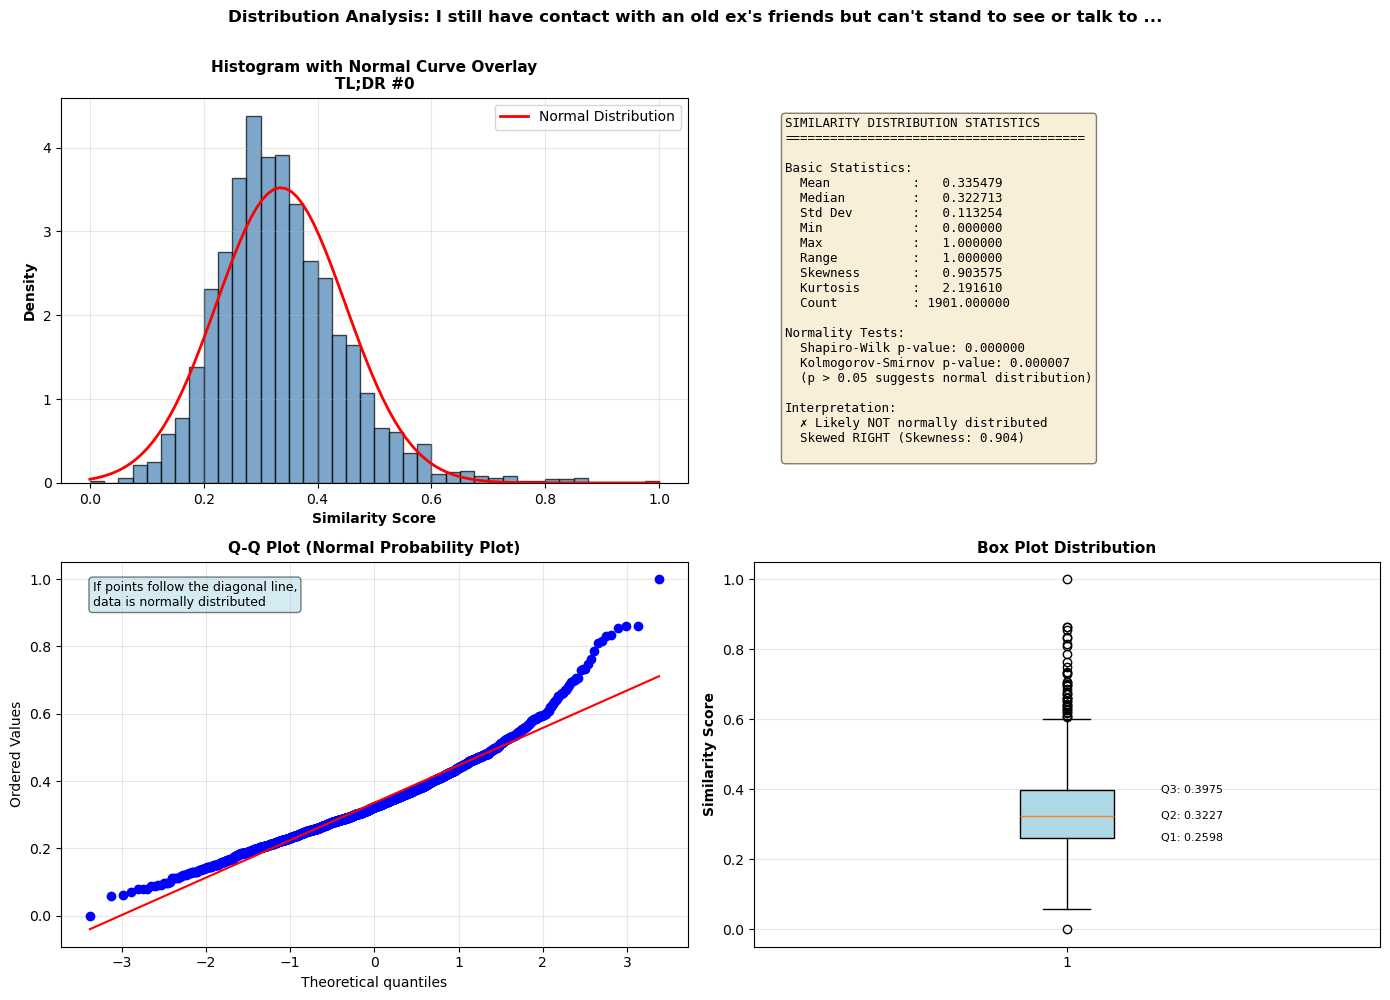

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

def analyze_similarity_distribution(df, row_idx=0):
    """
    Analyze and visualize the similarity distribution for a single TL;DR post.
    Shows:
    - Histogram with normal distribution overlay
    - Summary statistics
    - Q-Q plot for normality check
    - Box plot
    
    Args:
        df: DataFrame with 'all_similarities' column
        row_idx: which TL;DR post to analyze
    """
    row = df.iloc[row_idx]
    
    # Parse similarities
    similarities = np.array([float(x) for x in row['all_similarities'].split(';')])
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(14, 10))
    
    # ============================================
    # 1. HISTOGRAM WITH NORMAL DISTRIBUTION CURVE
    # ============================================
    ax1 = plt.subplot(2, 2, 1)
    
    # Calculate mean and std
    mean_sim = np.mean(similarities)
    std_sim = np.std(similarities)
    
    # Plot histogram
    counts, bins, patches = ax1.hist(similarities, bins=40, density=True, 
                                     alpha=0.7, color='steelblue', edgecolor='black')
    
    # Overlay normal distribution curve
    x = np.linspace(similarities.min(), similarities.max(), 100)
    normal_curve = stats.norm.pdf(x, mean_sim, std_sim)
    ax1.plot(x, normal_curve, 'r-', linewidth=2, label='Normal Distribution')
    
    ax1.set_xlabel('Similarity Score', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Density', fontsize=10, fontweight='bold')
    ax1.set_title(f'Histogram with Normal Curve Overlay\nTL;DR #{row_idx}', 
                  fontsize=11, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # ============================================
    # 2. STATISTICS BOX
    # ============================================
    ax2 = plt.subplot(2, 2, 2)
    ax2.axis('off')
    
    # Calculate statistics
    stats_dict = {
        'Mean': np.mean(similarities),
        'Median': np.median(similarities),
        'Std Dev': np.std(similarities),
        'Min': np.min(similarities),
        'Max': np.max(similarities),
        'Range': np.max(similarities) - np.min(similarities),
        'Skewness': stats.skew(similarities),
        'Kurtosis': stats.kurtosis(similarities),
        'Count': len(similarities)
    }
    
    # Perform normality tests
    shapiro_stat, shapiro_p = stats.shapiro(similarities)
    ks_stat, ks_p = stats.kstest(similarities, 'norm', args=(mean_sim, std_sim))
    
    # Create text summary
    stats_text = "SIMILARITY DISTRIBUTION STATISTICS\n"
    stats_text += "="*40 + "\n\n"
    
    stats_text += "Basic Statistics:\n"
    for key, value in stats_dict.items():
        stats_text += f"  {key:<15}: {value:>10.6f}\n"
    
    stats_text += "\nNormality Tests:\n"
    stats_text += f"  Shapiro-Wilk p-value: {shapiro_p:.6f}\n"
    stats_text += f"  Kolmogorov-Smirnov p-value: {ks_p:.6f}\n"
    stats_text += f"  (p > 0.05 suggests normal distribution)\n"
    
    stats_text += "\nInterpretation:\n"
    if shapiro_p > 0.05:
        stats_text += "  ✓ Likely NORMALLY distributed\n"
    else:
        stats_text += "  ✗ Likely NOT normally distributed\n"
    
    if stats_dict['Skewness'] > 0:
        stats_text += f"  Skewed RIGHT (Skewness: {stats_dict['Skewness']:.3f})\n"
    elif stats_dict['Skewness'] < 0:
        stats_text += f"  Skewed LEFT (Skewness: {stats_dict['Skewness']:.3f})\n"
    else:
        stats_text += "  SYMMETRIC (Skewness: 0)\n"
    
    ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, fontsize=9,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # ============================================
    # 3. Q-Q PLOT (normality check)
    # ============================================
    ax3 = plt.subplot(2, 2, 3)
    
    stats.probplot(similarities, dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot (Normal Probability Plot)', fontsize=11, fontweight='bold')
    ax3.grid(alpha=0.3)
    ax3.text(0.05, 0.95, 
             'If points follow the diagonal line,\ndata is normally distributed',
             transform=ax3.transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    # ============================================
    # 4. BOX PLOT
    # ============================================
    ax4 = plt.subplot(2, 2, 4)
    
    bp = ax4.boxplot(similarities, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    
    ax4.set_ylabel('Similarity Score', fontsize=10, fontweight='bold')
    ax4.set_title('Box Plot Distribution', fontsize=11, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add quartile values
    q1 = np.percentile(similarities, 25)
    q2 = np.percentile(similarities, 50)
    q3 = np.percentile(similarities, 75)
    
    ax4.text(1.15, q1, f"Q1: {q1:.4f}", fontsize=8, va='center')
    ax4.text(1.15, q2, f"Q2: {q2:.4f}", fontsize=8, va='center')
    ax4.text(1.15, q3, f"Q3: {q3:.4f}", fontsize=8, va='center')
    
    # Add title with completion text
    completion_text = row['completion'][:80] + '...'
    fig.suptitle(f'Distribution Analysis: {completion_text}', 
                 fontsize=12, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()
    
    return stats_dict, shapiro_p, ks_p

First we start with compute the similarities between one TL;DR post and all the Gen-Z slang word `Netrual Text` column word with their 

In [ ]:
# Step 1: Compute all similarities
df_train = train_ds.to_pandas()

df_with_sims = compute_all_similarities(
    df=df_train,
    genz_data=df_genz,
    model=model,
    slang_embeddings=slang_embeddings
)

df_with_sims.to_csv(basepath + "tldr.csv")


Computing similarities for each TL;DR...


Computing similarities: 100%|██████████| 116722/116722 [28:12<00:00, 68.95it/s] 


Similarity stats - Count: 1901, Mean: 0.3355, Std: 0.1133, Min: 0.0000, Max: 1.0000


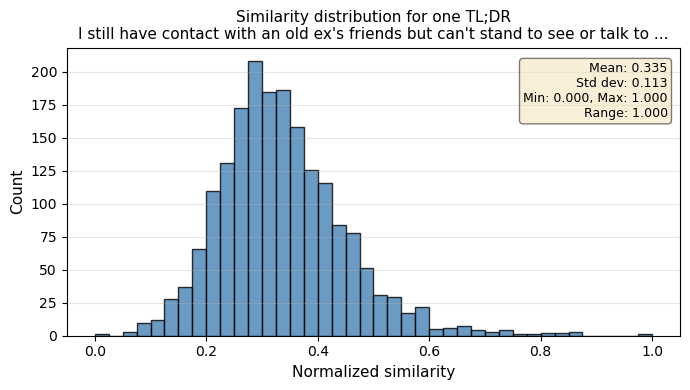

In [12]:
# Analyze first post's distribution
df_with_sims = pd.read_csv(basepath + "tldr.csv")

import matplotlib.pyplot as plt
import numpy as np

def analyze_similarity_distribution_simple(df, row_idx=0, bins=40):
    """
    Simple analysis of similarity distribution for one TL;DR post.
    - Histogram of similarities
    - Annotated with mean, std, min, max
    """
    row = df.iloc[row_idx]
    similarities = np.array([float(x) for x in row['all_similarities'].split(';')])

    mean_sim = similarities.mean()
    std_sim = similarities.std()
    sim_min = similarities.min()
    sim_max = similarities.max()
    print(f"Similarity stats - Count: {len(similarities)}, Mean: {mean_sim:.4f}, Std: {std_sim:.4f}, Min: {sim_min:.4f}, Max: {sim_max:.4f}")

    plt.figure(figsize=(7, 4))
    plt.hist(similarities, bins=bins, color='steelblue',
             edgecolor='black', alpha=0.8)
    plt.xlabel("Normalized similarity", fontsize=11)
    plt.ylabel("Count", fontsize=11)

    completion_text = row['completion'][:80] + "..."
    plt.title(f"Similarity distribution for one TL;DR\n{completion_text}",
              fontsize=11)

    # Text box with tightness info
    text = (
        f"Mean: {mean_sim:.3f}\n"
        f"Std dev: {std_sim:.3f}\n"
        f"Min: {sim_min:.3f}, Max: {sim_max:.3f}\n"
        f"Range: {sim_max - sim_min:.3f}"
    )
    plt.gca().text(0.98, 0.95, text, transform=plt.gca().transAxes,
                   ha="right", va="top",
                   bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
                   fontsize=9)

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "mean": mean_sim,
        "std": std_sim,
        "min": sim_min,
        "max": sim_max,
        "range": sim_max - sim_min,
    }

stats_dict = analyze_similarity_distribution_simple(df_with_sims, row_idx=0)

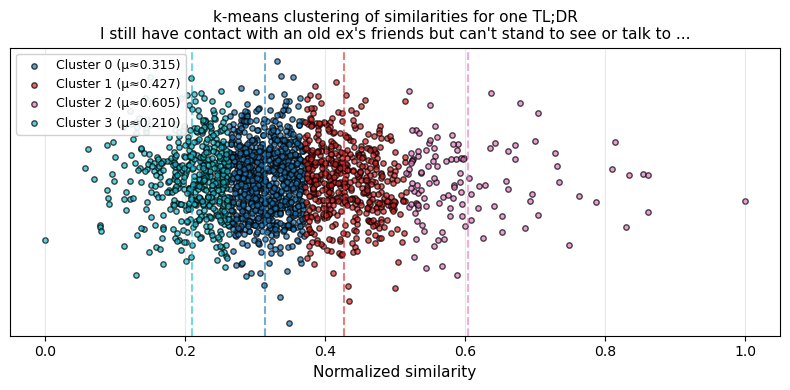

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def plot_similarity_kmeans_clusters(df, row_idx=0, n_clusters=3, random_state=0):
    """
    Cluster similarity scores for one TL;DR using 1D k-means and plot them.
    - X-axis: normalized similarity
    - Y-axis: jitter (no meaning, just for separation)
    - Color: k-means cluster
    """
    row = df.iloc[row_idx]
    sims = np.array([float(x) for x in row['all_similarities'].split(';')])

    # Reshape for sklearn (n_samples, n_features)
    sims_1d = sims.reshape(-1, 1)

    # Fit k-means on 1D similarities
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = km.fit_predict(sims_1d)
    centers = km.cluster_centers_.ravel()

    # Prepare plot
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    y = np.random.normal(0, 0.03, size=len(sims))  # jitter for vertical spread

    plt.figure(figsize=(8, 4))
    for k in range(n_clusters):
        mask = labels == k
        plt.scatter(
            sims[mask],
            y[mask],
            s=15,
            color=colors[k],
            edgecolor="k",
            alpha=0.7,
            label=f"Cluster {k} (μ≈{centers[k]:.3f})",
        )

    # Plot cluster centers as vertical lines
    for k, c in enumerate(centers):
        plt.axvline(c, color=colors[k], linestyle="--", alpha=0.6)

    plt.yticks([])
    plt.xlabel("Normalized similarity", fontsize=11)
    completion_text = row["completion"][:80] + "..."
    plt.title(f"k-means clustering of similarities for one TL;DR\n{completion_text}",
              fontsize=11)
    plt.grid(axis="x", alpha=0.3)
    plt.legend(loc="upper left", fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()

    return {
        "labels": labels,
        "centers": centers,
    }
kmeans_result = plot_similarity_kmeans_clusters(df_with_sims, row_idx=0, n_clusters=4)

In [4]:

# With top-p threshold visualization
plot_tldr_slang_distribution_with_top_p(
    df_with_sims, 
    row_idx=0, 
    top_n=30, 
    top_p=0.01,
    show_threshold=True
)

# Try different top-p values
plot_tldr_slang_distribution_with_top_p(
    df_with_sims, 
    row_idx=0, 
    top_n=30, 
    top_p=0.05
)

# Without threshold (just bars)
plot_tldr_slang_distribution_with_top_p(
    df_with_sims, 
    row_idx=0, 
    top_n=10,
    show_threshold=False
)


NameError: name 'plot_tldr_slang_distribution_with_top_p' is not defined

In [13]:
display(df_with_sims.head(5))

,Unnamed: 0,prompt,completion,all_slang,all_similarities
0,0,SUBREDDIT: r/relationships TITLE: I (f/22) hav...,I still have contact with an old ex's friends ...,"""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.324210;0.306928;0.253868;0.272921;0.704904;0...
1,1,SUBREDDIT: r/loseit TITLE: SV & NSV! Keeping o...,"Progress is still happening, even when you thi...","""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.498610;0.605956;0.586507;0.468540;0.389142;0...
2,2,SUBREDDIT: r/relationships TITLE: Me [19F] wit...,My skin is scarred badly; what could I do/say ...,"""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.325442;0.182998;0.291735;0.212317;0.294495;0...
3,3,SUBREDDIT: r/personalfinance TITLE: Prioritize...,$14k in student debt (all <5%) and need to sav...,"""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.326683;0.541999;0.547360;0.404891;0.393326;0...
4,4,SUBREDDIT: r/relationships TITLE: My[25m] girl...,"GF is a meanie-bo-beanie when I'm nice, and an...","""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.480018;0.383189;0.271994;0.498448;0.398034;0...


In [22]:
# Step 2: Apply top-p selection
#df_final = apply_top_p_selection(df_with_sims, top_p=0.01)
# Step 3. Use top k selection of 8 slang words
df_final = apply_top_k_selection(df_with_sims, max_k=8)

# Step 3: Sample from relevant slang
#df_final = sample_slang_column(df_with_relevant, sample_ratio=0.7)

df_final.to_csv(basepath + "tldr_top_k.csv")
print("Saved: tldr_top_k.csv")


Selecting top-8 slang words...


Selecting top-k slang: 100%|██████████| 116722/116722 [02:35<00:00, 752.98it/s]


✓ Selected top-8 slang words
  Added columns: ['top_k_slang', 'top_k_slang_count']

Saved: tldr_top_k.csv


In [25]:
display(df_final.head(5))

,Unnamed: 0,prompt,completion,all_slang,all_similarities,top_k_slang,top_k_slang_count
0,0,SUBREDDIT: r/relationships TITLE: I (f/22) hav...,I still have contact with an old ex's friends ...,"""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.324210;0.306928;0.253868;0.272921;0.704904;0...,FBFR; Zombie-ing; BFFN; Thirsty; AAYF; FWB; FB...,8
1,1,SUBREDDIT: r/loseit TITLE: SV & NSV! Keeping o...,"Progress is still happening, even when you thi...","""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.498610;0.605956;0.586507;0.468540;0.389142;0...,NSA; WB; DITYID; FISH; AYDY; Hits Different; D...,8
2,2,SUBREDDIT: r/relationships TITLE: Me [19F] wit...,My skin is scarred badly; what could I do/say ...,"""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.325442;0.182998;0.291735;0.212317;0.294495;0...,DIY; IAAD; MYOB; Snatched; Beat your face; OMA...,8
3,3,SUBREDDIT: r/personalfinance TITLE: Prioritize...,$14k in student debt (all <5%) and need to sav...,"""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.326683;0.541999;0.547360;0.404891;0.393326;0...,IAAA; Sheesh; WDYT; DYOR; Gaup; TM; BOHICA; AFAP,8
4,4,SUBREDDIT: r/relationships TITLE: My[25m] girl...,"GF is a meanie-bo-beanie when I'm nice, and an...","""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.480018;0.383189;0.271994;0.498448;0.398034;0...,GF; KOC; G/F; PYT; GRL; HUYA; IWSN; LHSX,8


In [38]:
# ============================================
# STEP 1: Compute similarities for all TL;DRs
# ============================================
print("\\nStep 1: Computing similarities...")
similarity_data = pd.DataFrame()
    
for completion in tqdm(tldr_df_train['completion'], desc="Computing similarities"):
    sim_result = compute_similarities(completion, model, slang_embeddings, df_genz)
    similarity_data = similarity_data.(sim_result)

# Add similarity columns to dataframe
for key in similarity_data[0].keys():
    tldr_df_train[key] = [result[key] for result in similarity_data]

print(f"✓ Computed similarities for {len(tldr_df_train)} TL;DRs")
print(f"  Columns added: {list(similarity_data[0].keys())}")

\nStep 1: Computing similarities...


Computing similarities:   0%|          | 0/5 [00:00<?, ?it/s]


TypeError: Can only merge Series or DataFrame objects, a <class 'dict'> was passed